# Visualize some merged data for EDA processing

# Attempt 1: Quan hệ giữa sales và inventory
inventory.csv + sales.csv

In [4]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu từ file CSV
df_sales = pd.read_csv('../dataset/sales.csv')
df_inventory = pd.read_csv('../dataset/inventory.csv')

# ==========================================
# 2. XỬ LÝ & TỔNG HỢP DỮ LIỆU SALES
# ==========================================
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
# Tạo cột 'year_month' (VD: '2022-10') để làm khóa kết nối
df_sales['year_month'] = df_sales['Date'].dt.to_period('M')

# Nhóm theo tháng và tính tổng Doanh thu, Giá vốn hàng bán
monthly_sales = df_sales.groupby('year_month')[['Revenue', 'COGS']].sum().reset_index()

# Tính thêm Lợi nhuận gộp (Gross Profit)
monthly_sales['Gross_Profit'] = monthly_sales['Revenue'] - monthly_sales['COGS']


# ==========================================
# 3. XỬ LÝ & TỔNG HỢP DỮ LIỆU INVENTORY
# ==========================================
# Sử dụng cột 'year' và 'month' có sẵn để tạo cột 'year_month' chuẩn tương tự file sales
df_inventory['year_month'] = pd.to_datetime(
    df_inventory['year'].astype(str) + '-' + df_inventory['month'].astype(str)
).dt.to_period('M')

# Nhóm các chỉ số kho quan trọng theo tháng
monthly_inventory = df_inventory.groupby('year_month').agg(
    total_stock_on_hand=('stock_on_hand', 'sum'),
    total_units_received=('units_received', 'sum'),
    total_units_sold=('units_sold', 'sum'),
    total_stockout_days=('stockout_days', 'sum'),
    avg_fill_rate=('fill_rate', 'mean')
).reset_index()


# ==========================================
# 4. MERGE VÀ TÍNH TOÁN CÁC CHỈ SỐ MỐI QUAN HỆ
# ==========================================
# Gộp 2 DataFrame lại theo tháng (sử dụng inner join để lấy các tháng xuất hiện ở cả 2 bảng)
df_merged = pd.merge(monthly_sales, monthly_inventory, on='year_month', how='inner')

# Tính toán một số thuộc tính quan trọng để đánh giá mối quan hệ:
# a. Tương quan Giá vốn hàng bán (COGS) trên số lượng tồn kho (Chi phí trung bình ẩn)
df_merged['COGS_per_Stock_Unit'] = df_merged['COGS'] / df_merged['total_stock_on_hand'].replace(0, np.nan)

# b. Tương quan Doanh thu trên lượng hàng bán ra (Giá bán trung bình ước tính trên 1 đơn vị)
df_merged['Revenue_per_Unit_Sold'] = df_merged['Revenue'] / df_merged['total_units_sold'].replace(0, np.nan)

# c. Tỷ lệ mất doanh thu tiềm năng do thiếu hàng (Đo lường tác động của stockout_days lên Revenue)
# Giả định: Doanh thu trung bình mỗi ngày * số ngày hết hàng
revenue_per_day = df_merged['Revenue'] / 30 
df_merged['Estimated_Lost_Revenue'] = revenue_per_day * df_merged['total_stockout_days']

# ==========================================
# 5. HIỂN THỊ KẾT QUẢ VÀ MA TRẬN TƯƠNG QUAN
# ==========================================
print("Dữ liệu sau khi gộp (5 dòng đầu tiên):")
display(df_merged.head())

print("\nMa trận tương quan (Pearson Correlation) giữa các chỉ số chính:")
# Đánh giá độ tương quan tuyến tính giữa Doanh thu/Lợi nhuận với Lượng tồn kho, Ngày thiếu hàng...
metrics_to_correlate = [
    'Revenue', 'COGS', 'Gross_Profit', 
    'total_stock_on_hand', 'total_units_sold', 'total_stockout_days', 'avg_fill_rate'
]
display(df_merged[metrics_to_correlate].corr())

Dữ liệu sau khi gộp (5 dòng đầu tiên):


,year_month,Revenue,COGS,Gross_Profit,total_stock_on_hand,total_units_received,total_units_sold,total_stockout_days,avg_fill_rate,COGS_per_Stock_Unit,Revenue_per_Unit_Sold,Estimated_Lost_Revenue
0,2012-07,1.304068e+08,1.025165e+08,27890299.64,23698,8796,7451,402,0.966075,4325.954674,17501.915650,1.747451e+09
1,2012-08,1.590892e+08,1.255853e+08,33503933.88,26249,11799,9983,699,0.944919,4784.384412,15936.015257,3.706779e+09
2,2012-09,1.293071e+08,1.025962e+08,26710979.00,27519,8552,7303,636,0.950001,3728.193423,17706.029552,2.741311e+09
3,2012-10,1.101857e+08,8.805481e+07,22130889.42,29194,7732,6622,621,0.952631,3016.195281,16639.337730,2.280844e+09
4,2012-11,9.818630e+07,7.782008e+07,20366217.83,30134,7276,6251,495,0.959855,2582.467559,15707.294071,1.620074e+09



Ma trận tương quan (Pearson Correlation) giữa các chỉ số chính:


,Revenue,COGS,Gross_Profit,total_stock_on_hand,total_units_sold,total_stockout_days,avg_fill_rate
Revenue,1.000000,0.971508,0.720580,-0.182083,0.880748,0.649045,-0.432447
COGS,0.971508,1.000000,0.535717,-0.167037,0.919108,0.674619,-0.437360
Gross_Profit,0.720580,0.535717,1.000000,-0.160044,0.449010,0.338771,-0.261192
total_stock_on_hand,-0.182083,-0.167037,-0.160044,1.000000,-0.392165,-0.190743,0.471079
total_units_sold,0.880748,0.919108,0.449010,-0.392165,1.000000,0.727288,-0.572196
total_stockout_days,0.649045,0.674619,0.338771,-0.190743,0.727288,1.000000,-0.863064
avg_fill_rate,-0.432447,-0.437360,-0.261192,0.471079,-0.572196,-0.863064,1.000000


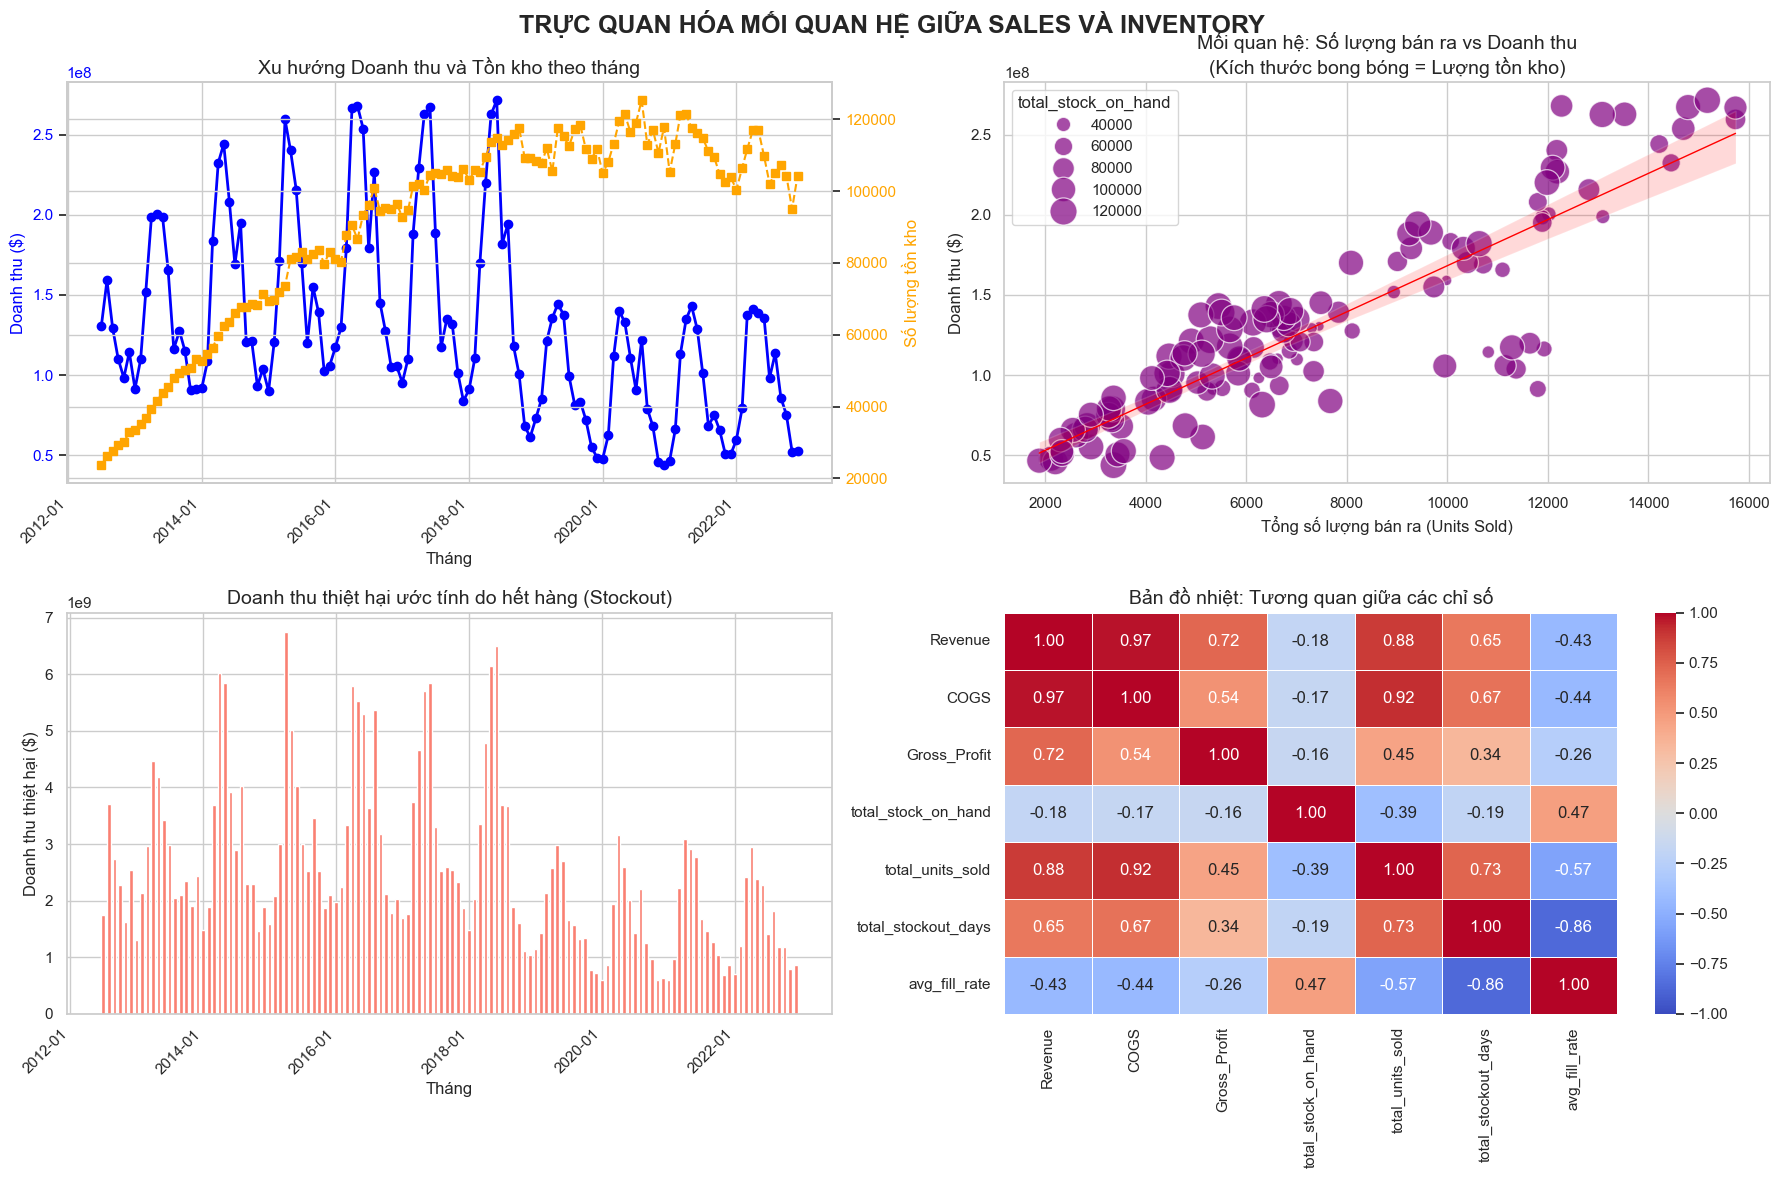

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

sns.set_theme(style="whitegrid")

# ==========================================
# FIX TRỤC X: Chuyển Period sang Datetime chuẩn
# ==========================================
df_merged['month_dt'] = df_merged['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('TRỰC QUAN HÓA MỐI QUAN HỆ GIỮA SALES VÀ INVENTORY', fontsize=18, fontweight='bold')

# ==========================================
# 1. BIỂU ĐỒ ĐƯỜNG 2 TRỤC (Đã fix trục X)
# ==========================================
ax1 = axes[0, 0]
ax1.plot(df_merged['month_dt'], df_merged['Revenue'], color='blue', marker='o', label='Revenue', linewidth=2)
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Doanh thu ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(df_merged['month_dt'], df_merged['total_stock_on_hand'], color='orange', marker='s', linestyle='--', label='Stock on Hand')
ax2.set_ylabel('Số lượng tồn kho', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Ép định dạng ngày hiển thị thành YYYY-MM và xoay 45 độ
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right') # ha='right' giúp nhãn không bị lệch
ax1.set_title('Xu hướng Doanh thu và Tồn kho theo tháng', fontsize=14)

# ==========================================
# 2. SCATTER PLOT (Giữ nguyên)
# ==========================================
sns.scatterplot(
    data=df_merged, x='total_units_sold', y='Revenue', 
    size='total_stock_on_hand', sizes=(50, 400), alpha=0.7, ax=axes[0, 1], color='purple'
)
sns.regplot(data=df_merged, x='total_units_sold', y='Revenue', scatter=False, ax=axes[0, 1], color='red', line_kws={"linewidth":1})
axes[0, 1].set_title('Mối quan hệ: Số lượng bán ra vs Doanh thu\n(Kích thước bong bóng = Lượng tồn kho)', fontsize=14)
axes[0, 1].set_xlabel('Tổng số lượng bán ra (Units Sold)')
axes[0, 1].set_ylabel('Doanh thu ($)')

# ==========================================
# 3. BAR CHART (Đã fix trục X)
# ==========================================
# Dùng matplotlib bar thay vì seaborn barplot để trục X datetime đồng bộ hoàn hảo
# width=20 (tính bằng ngày) giúp các cột có độ rộng vừa phải
axes[1, 0].bar(df_merged['month_dt'], df_merged['Estimated_Lost_Revenue'], color='salmon', width=20)
axes[1, 0].set_title('Doanh thu thiệt hại ước tính do hết hàng (Stockout)', fontsize=14)
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('Doanh thu thiệt hại ($)')

# Ép định dạng và xoay nhãn tương tự biểu đồ đường
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# ==========================================
# 4. HEATMAP (Giữ nguyên)
# ==========================================
corr_cols = ['Revenue', 'COGS', 'Gross_Profit', 'total_stock_on_hand', 
             'total_units_sold', 'total_stockout_days', 'avg_fill_rate']
corr_matrix = df_merged[corr_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    vmin=-1, vmax=1, linewidths=.5, ax=axes[1, 1]
)
axes[1, 1].set_title('Bản đồ nhiệt: Tương quan giữa các chỉ số', fontsize=14)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

# Attempt 2
web_traffic.csv

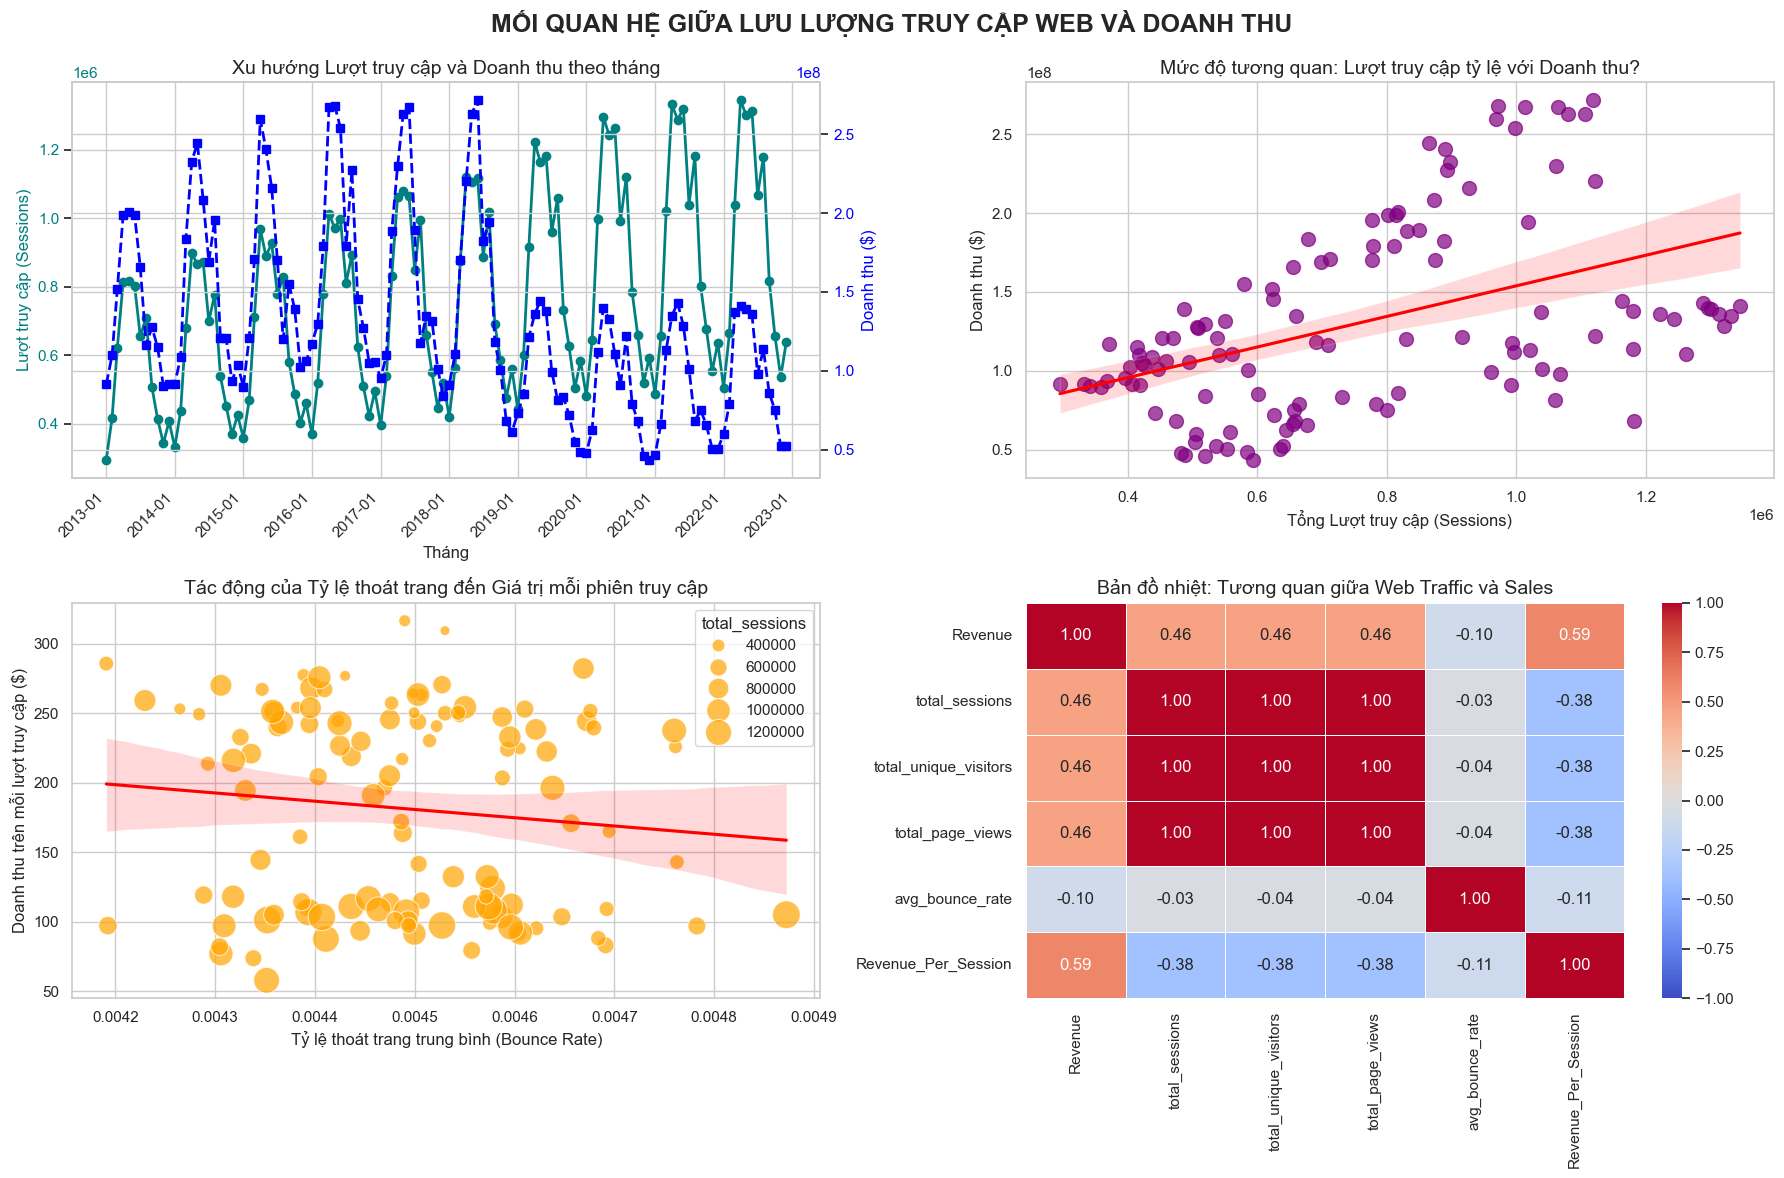

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
# Đọc 2 file dữ liệu
df_sales = pd.read_csv('../dataset/sales.csv')
df_web = pd.read_csv('../dataset/web_traffic.csv')

# Xử lý ngày tháng cho Sales và tổng hợp Doanh thu theo tháng
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['year_month'] = df_sales['Date'].dt.to_period('M')
monthly_sales = df_sales.groupby('year_month')['Revenue'].sum().reset_index()

# Xử lý ngày tháng cho Web Traffic và tổng hợp các chỉ số theo tháng
df_web['date'] = pd.to_datetime(df_web['date'])
df_web['year_month'] = df_web['date'].dt.to_period('M')
monthly_web = df_web.groupby('year_month').agg(
    total_sessions=('sessions', 'sum'),
    total_unique_visitors=('unique_visitors', 'sum'),
    total_page_views=('page_views', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean')
).reset_index()

# ==========================================
# 2. GỘP DỮ LIỆU VÀ CHUẨN BỊ VẼ
# ==========================================
# Gộp 2 bảng lại theo tháng
df_marketing_sales = pd.merge(monthly_sales, monthly_web, on='year_month', how='inner')

# Chuyển Period sang Datetime để vẽ trục X không bị lỗi
df_marketing_sales['month_dt'] = df_marketing_sales['year_month'].dt.to_timestamp()

# Tính giá trị mỗi phiên (Revenue Per Session)
df_marketing_sales['Revenue_Per_Session'] = df_marketing_sales['Revenue'] / df_marketing_sales['total_sessions']

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('MỐI QUAN HỆ GIỮA LƯU LƯỢNG TRUY CẬP WEB VÀ DOANH THU', fontsize=18, fontweight='bold')

# --- BIỂU ĐỒ 1: Xu hướng Sessions và Revenue theo thời gian (Dual-axis) ---
ax1 = axes[0, 0]
ax1.plot(df_marketing_sales['month_dt'], df_marketing_sales['total_sessions'], color='teal', marker='o', linewidth=2, label='Sessions')
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Lượt truy cập (Sessions)', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(df_marketing_sales['month_dt'], df_marketing_sales['Revenue'], color='blue', marker='s', linestyle='--', linewidth=2, label='Revenue')
ax2.set_ylabel('Doanh thu ($)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_title('Xu hướng Lượt truy cập và Doanh thu theo tháng', fontsize=14)

# --- BIỂU ĐỒ 2: Scatter Plot (Lượt truy cập vs Doanh thu) ---
sns.regplot(
    data=df_marketing_sales, x='total_sessions', y='Revenue', 
    ax=axes[0, 1], scatter_kws={'s': 100, 'alpha': 0.7, 'color': 'purple'}, line_kws={'color': 'red'}
)
axes[0, 1].set_title('Mức độ tương quan: Lượt truy cập tỷ lệ với Doanh thu?', fontsize=14)
axes[0, 1].set_xlabel('Tổng Lượt truy cập (Sessions)')
axes[0, 1].set_ylabel('Doanh thu ($)')

# --- BIỂU ĐỒ 3: Scatter Plot (Tỷ lệ thoát trang vs Giá trị mỗi phiên) ---
sns.scatterplot(
    data=df_marketing_sales, x='avg_bounce_rate', y='Revenue_Per_Session', 
    size='total_sessions', sizes=(50, 400), alpha=0.7, ax=axes[1, 0], color='orange'
)
# Thêm đường xu hướng
sns.regplot(data=df_marketing_sales, x='avg_bounce_rate', y='Revenue_Per_Session', scatter=False, ax=axes[1, 0], color='red')
axes[1, 0].set_title('Tác động của Tỷ lệ thoát trang đến Giá trị mỗi phiên truy cập', fontsize=14)
axes[1, 0].set_xlabel('Tỷ lệ thoát trang trung bình (Bounce Rate)')
axes[1, 0].set_ylabel('Doanh thu trên mỗi lượt truy cập ($)')

# --- BIỂU ĐỒ 4: Ma trận tương quan (Heatmap) ---
corr_cols = [
    'Revenue', 'total_sessions', 'total_unique_visitors', 
    'total_page_views', 'avg_bounce_rate', 'Revenue_Per_Session'
]
corr_matrix = df_marketing_sales[corr_cols].corr()

sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
    vmin=-1, vmax=1, linewidths=.5, ax=axes[1, 1]
)
axes[1, 1].set_title('Bản đồ nhiệt: Tương quan giữa Web Traffic và Sales', fontsize=14)

# Căn chỉnh hiển thị
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

# Attempt 3: Tương quan giữa truy cập vào web và doanh thu
web_traffic.csv + sales (correlation between sales and methods)

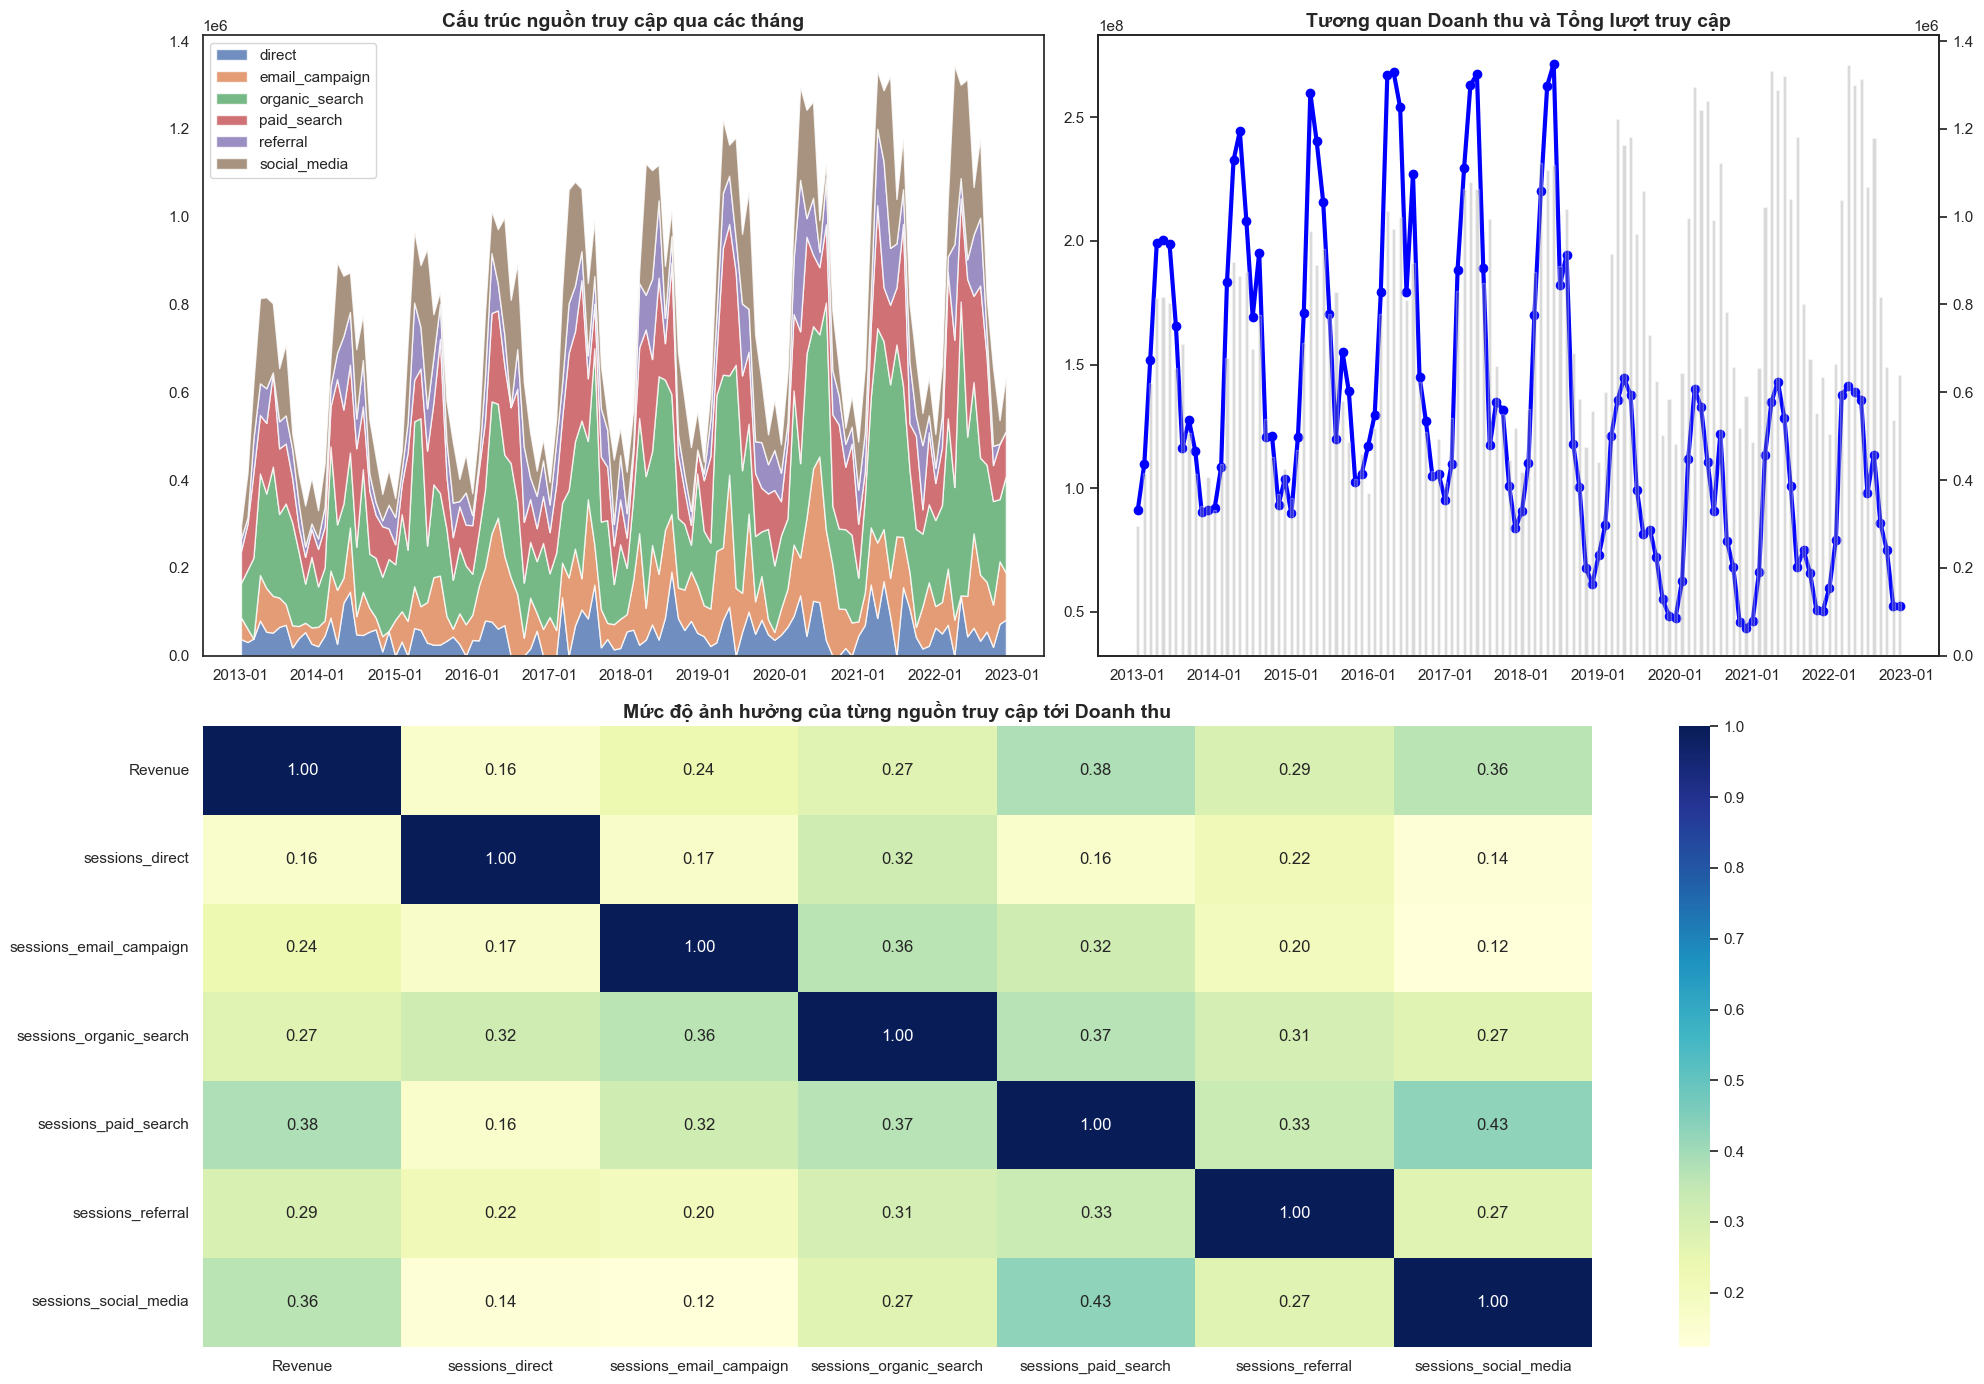

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. XỬ LÝ DỮ LIỆU SALES (NHƯ CŨ)
# ==========================================
df_sales = pd.read_csv('../dataset/sales.csv')
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['year_month'] = df_sales['Date'].dt.to_period('M')
monthly_sales = df_sales.groupby('year_month')['Revenue'].sum().reset_index()

# ==========================================
# 2. XỬ LÝ WEB TRAFFIC THEO TỪNG PHƯƠNG THỨC (TRAFFIC SOURCE)
# ==========================================
df_web = pd.read_csv('../dataset/web_traffic.csv')
df_web['date'] = pd.to_datetime(df_web['date'])
df_web['year_month'] = df_web['date'].dt.to_period('M')

# Xoay bảng (Pivot) để mỗi nguồn truy cập là một cột, giá trị là tổng sessions
traffic_pivot = df_web.pivot_table(
    index='year_month', 
    columns='traffic_source', 
    values='sessions', 
    aggfunc='sum'
).fillna(0).reset_index()

# Đổi tên các cột để dễ nhận biết (VD: sessions_organic_search)
traffic_pivot.columns = [f"sessions_{col}" if col != 'year_month' else col for col in traffic_pivot.columns]

# ==========================================
# 3. GỘP DỮ LIỆU & TRỰC QUAN HÓA
# ==========================================
df_final = pd.merge(monthly_sales, traffic_pivot, on='year_month', how='inner')
df_final['month_dt'] = df_final['year_month'].dt.to_timestamp()

sns.set_theme(style="white")
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(2, 2)

# --- BIỂU ĐỒ 1: Phân bổ nguồn truy cập theo thời gian (Stacked Area Chart) ---
ax1 = fig.add_subplot(gs[0, 0])
session_cols = [c for c in df_final.columns if 'sessions_' in c]
ax1.stackplot(df_final['month_dt'], [df_final[c] for c in session_cols], labels=[c.replace('sessions_', '') for c in session_cols], alpha=0.8)
ax1.set_title('Cấu trúc nguồn truy cập qua các tháng', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- BIỂU ĐỒ 2: Doanh thu vs Tổng lượt truy cập ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(df_final['month_dt'], df_final['Revenue'], color='blue', marker='o', linewidth=3, label='Revenue')
ax2_twin = ax2.twinx()
total_sessions = df_final[session_cols].sum(axis=1)
ax2_twin.bar(df_final['month_dt'], total_sessions, color='gray', alpha=0.3, width=15, label='Total Sessions')
ax2.set_title('Tương quan Doanh thu và Tổng lượt truy cập', fontsize=14, fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- BIỂU ĐỒ 3: Ma trận tương quan chi tiết giữa từng nguồn và Doanh thu ---
ax3 = fig.add_subplot(gs[1, :])
# Chỉ lấy các cột sessions và Revenue để tính tương quan
corr_cols = ['Revenue'] + session_cols
corr_matrix = df_final[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f", ax=ax3)
ax3.set_title('Mức độ ảnh hưởng của từng nguồn truy cập tới Doanh thu', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Attempt 3: Doanh thu và doanh thu theo khu vực
orders.csv + geography.csv + order_items.csv

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_46402/3945677754.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_items = pd.read_csv('../dataset/order_items.csv')


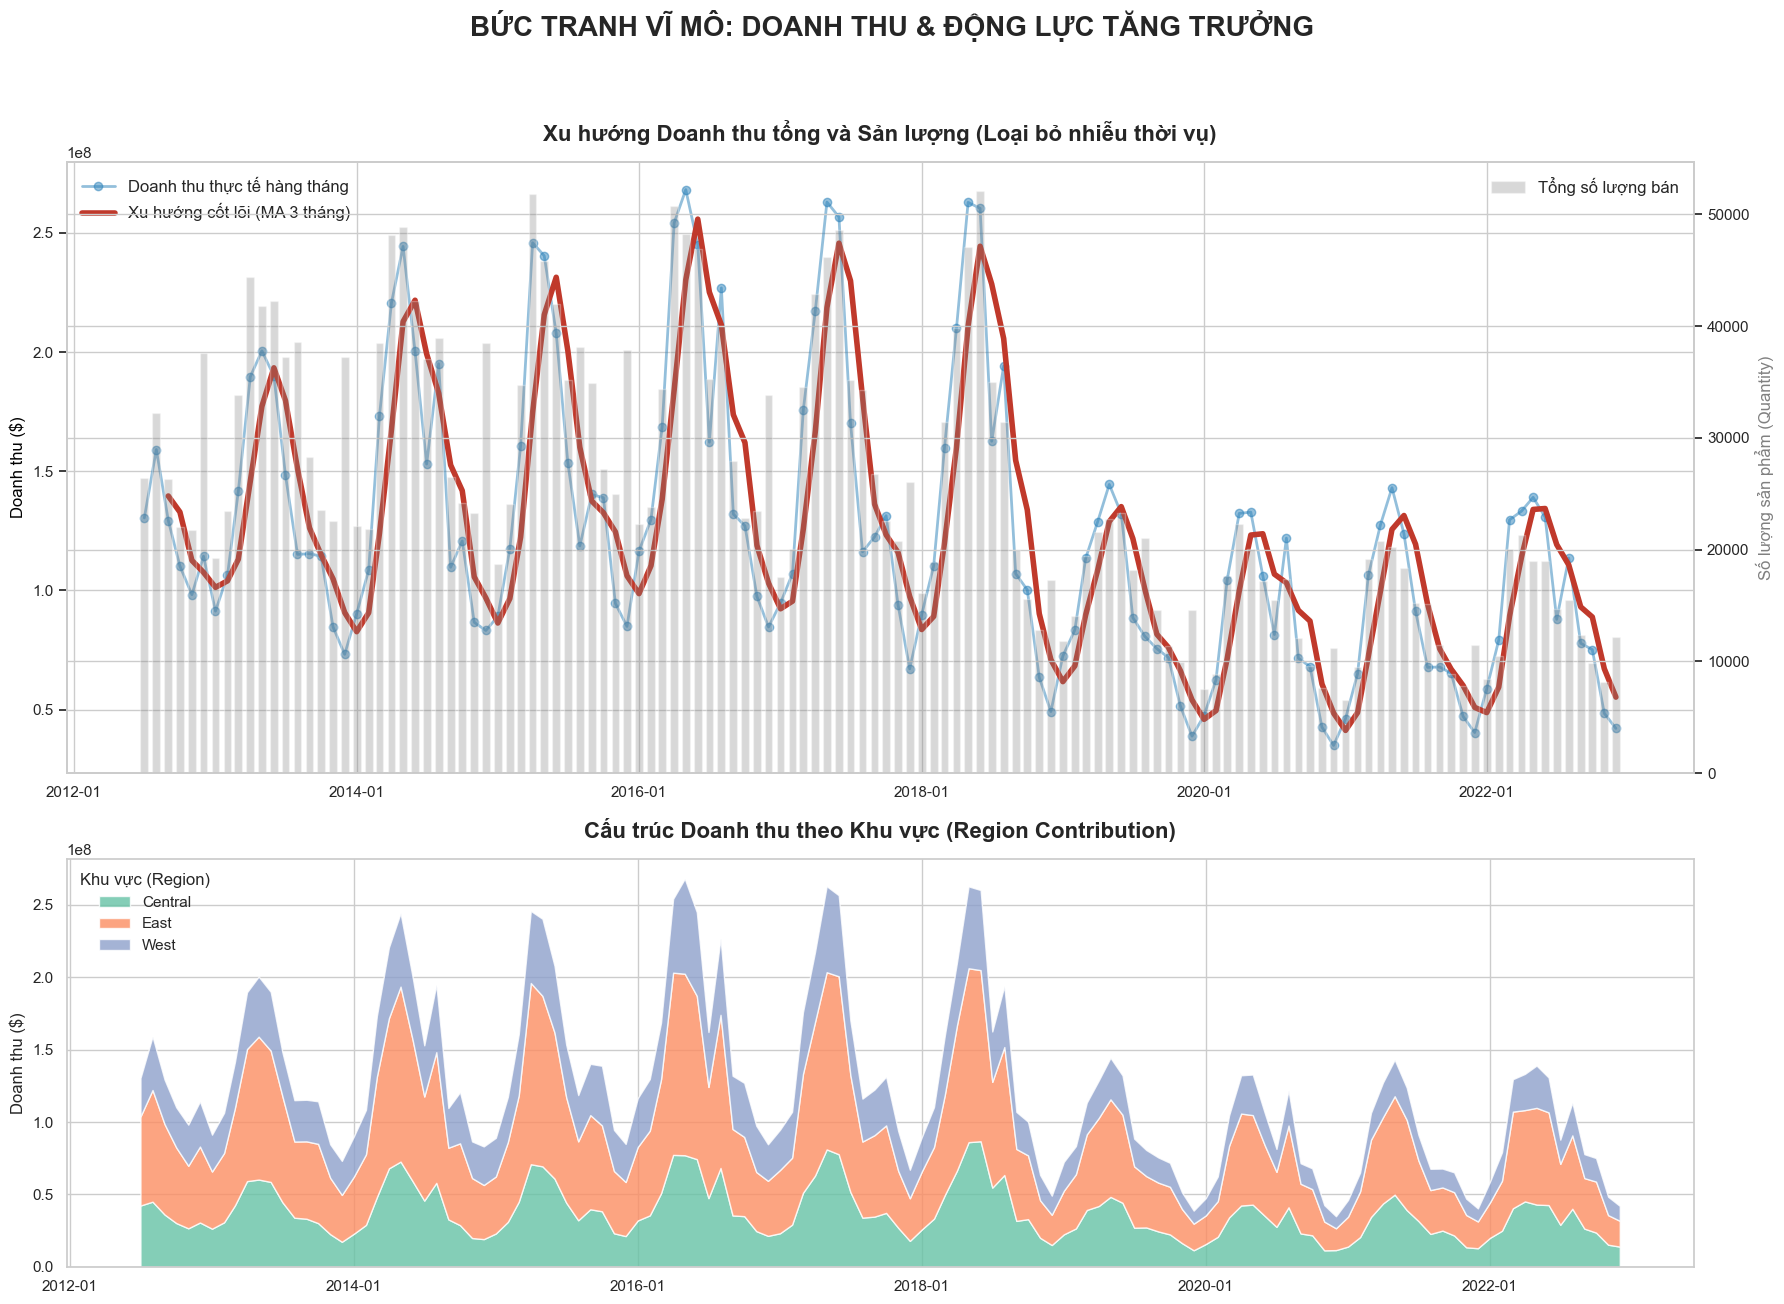

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. ĐỌC VÀ GỘP DỮ LIỆU (Giữ nguyên)
# ==========================================
df_orders = pd.read_csv('../dataset/orders.csv')
df_items = pd.read_csv('../dataset/order_items.csv')
df_geo = pd.read_csv('../dataset/geography.csv')

df_merge = pd.merge(df_orders, df_items, on='order_id')
df_final = pd.merge(df_merge, df_geo, on='zip')

# ==========================================
# 2. TIỀN XỬ LÝ CHO XU HƯỚNG VĨ MÔ
# ==========================================
df_final['order_date'] = pd.to_datetime(df_final['order_date'])
df_final['month_dt'] = df_final['order_date'].dt.to_period('M').dt.to_timestamp()
df_final['revenue'] = (df_final['quantity'] * df_final['unit_price']) - df_final['discount_amount']

# Tổng hợp dữ liệu toàn cục theo tháng
macro_trend = df_final.groupby('month_dt').agg(
    total_revenue=('revenue', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

# Tính đường trung bình động 3 tháng (3-Month Moving Average) để thấy rõ xu hướng dài hạn
macro_trend['revenue_ma3'] = macro_trend['total_revenue'].rolling(window=3).mean()

# Tổng hợp dữ liệu theo Khu vực (Region)
region_trend = df_final.groupby(['month_dt', 'region'])['revenue'].sum().unstack().fillna(0)

# ==========================================
# 3. TRỰC QUAN HÓA XU HƯỚNG LỚN
# ==========================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 1, height_ratios=[1.5, 1]) # Biểu đồ trên to hơn biểu đồ dưới
fig.suptitle('BỨC TRANH VĨ MÔ: DOANH THU & ĐỘNG LỰC TĂNG TRƯỞNG', fontsize=20, fontweight='bold', y=0.96)

# --- BIỂU ĐỒ 1: Sức khỏe tổng thể (Doanh thu, Sản lượng & Xu hướng dài hạn) ---
ax1 = fig.add_subplot(gs[0])

# Cột sản lượng (nền mờ)
ax1_twin = ax1.twinx()
ax1_twin.bar(macro_trend['month_dt'], macro_trend['total_quantity'], color='gray', alpha=0.3, width=20, label='Tổng số lượng bán')
ax1_twin.set_ylabel('Số lượng sản phẩm (Quantity)', color='gray', fontsize=12)

# Đường doanh thu thực tế
ax1.plot(macro_trend['month_dt'], macro_trend['total_revenue'], color='#2980b9', marker='o', linewidth=2, alpha=0.5, label='Doanh thu thực tế hàng tháng')

# Đường xu hướng cốt lõi (Moving Average)
ax1.plot(macro_trend['month_dt'], macro_trend['revenue_ma3'], color='#c0392b', linewidth=4, label='Xu hướng cốt lõi (MA 3 tháng)')

ax1.set_title('Xu hướng Doanh thu tổng và Sản lượng (Loại bỏ nhiễu thời vụ)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Doanh thu ($)', color='black', fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.legend(loc='upper left', fontsize=12)
ax1_twin.legend(loc='upper right', fontsize=12)

# --- BIỂU ĐỒ 2: Động lực Vùng miền (Stacked Area) ---
ax2 = fig.add_subplot(gs[1])
# Dùng Stacked Area để thấy cả quy mô tổng lẫn tỷ trọng của từng vùng
ax2.stackplot(
    region_trend.index, 
    [region_trend[col] for col in region_trend.columns], 
    labels=region_trend.columns, 
    alpha=0.8,
    colors=sns.color_palette("Set2", len(region_trend.columns))
)

ax2.set_title('Cấu trúc Doanh thu theo Khu vực (Region Contribution)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Doanh thu ($)', fontsize=12)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.legend(loc='upper left', title='Khu vực (Region)')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# Attempt 4: Thể hiện xu hướng sử dụng promo của công ty
file: promotions.csv + other_items.csv

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/3157351348.py:7: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orders = pd.read_csv('../dataset/order_items.csv')
/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/3157351348.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


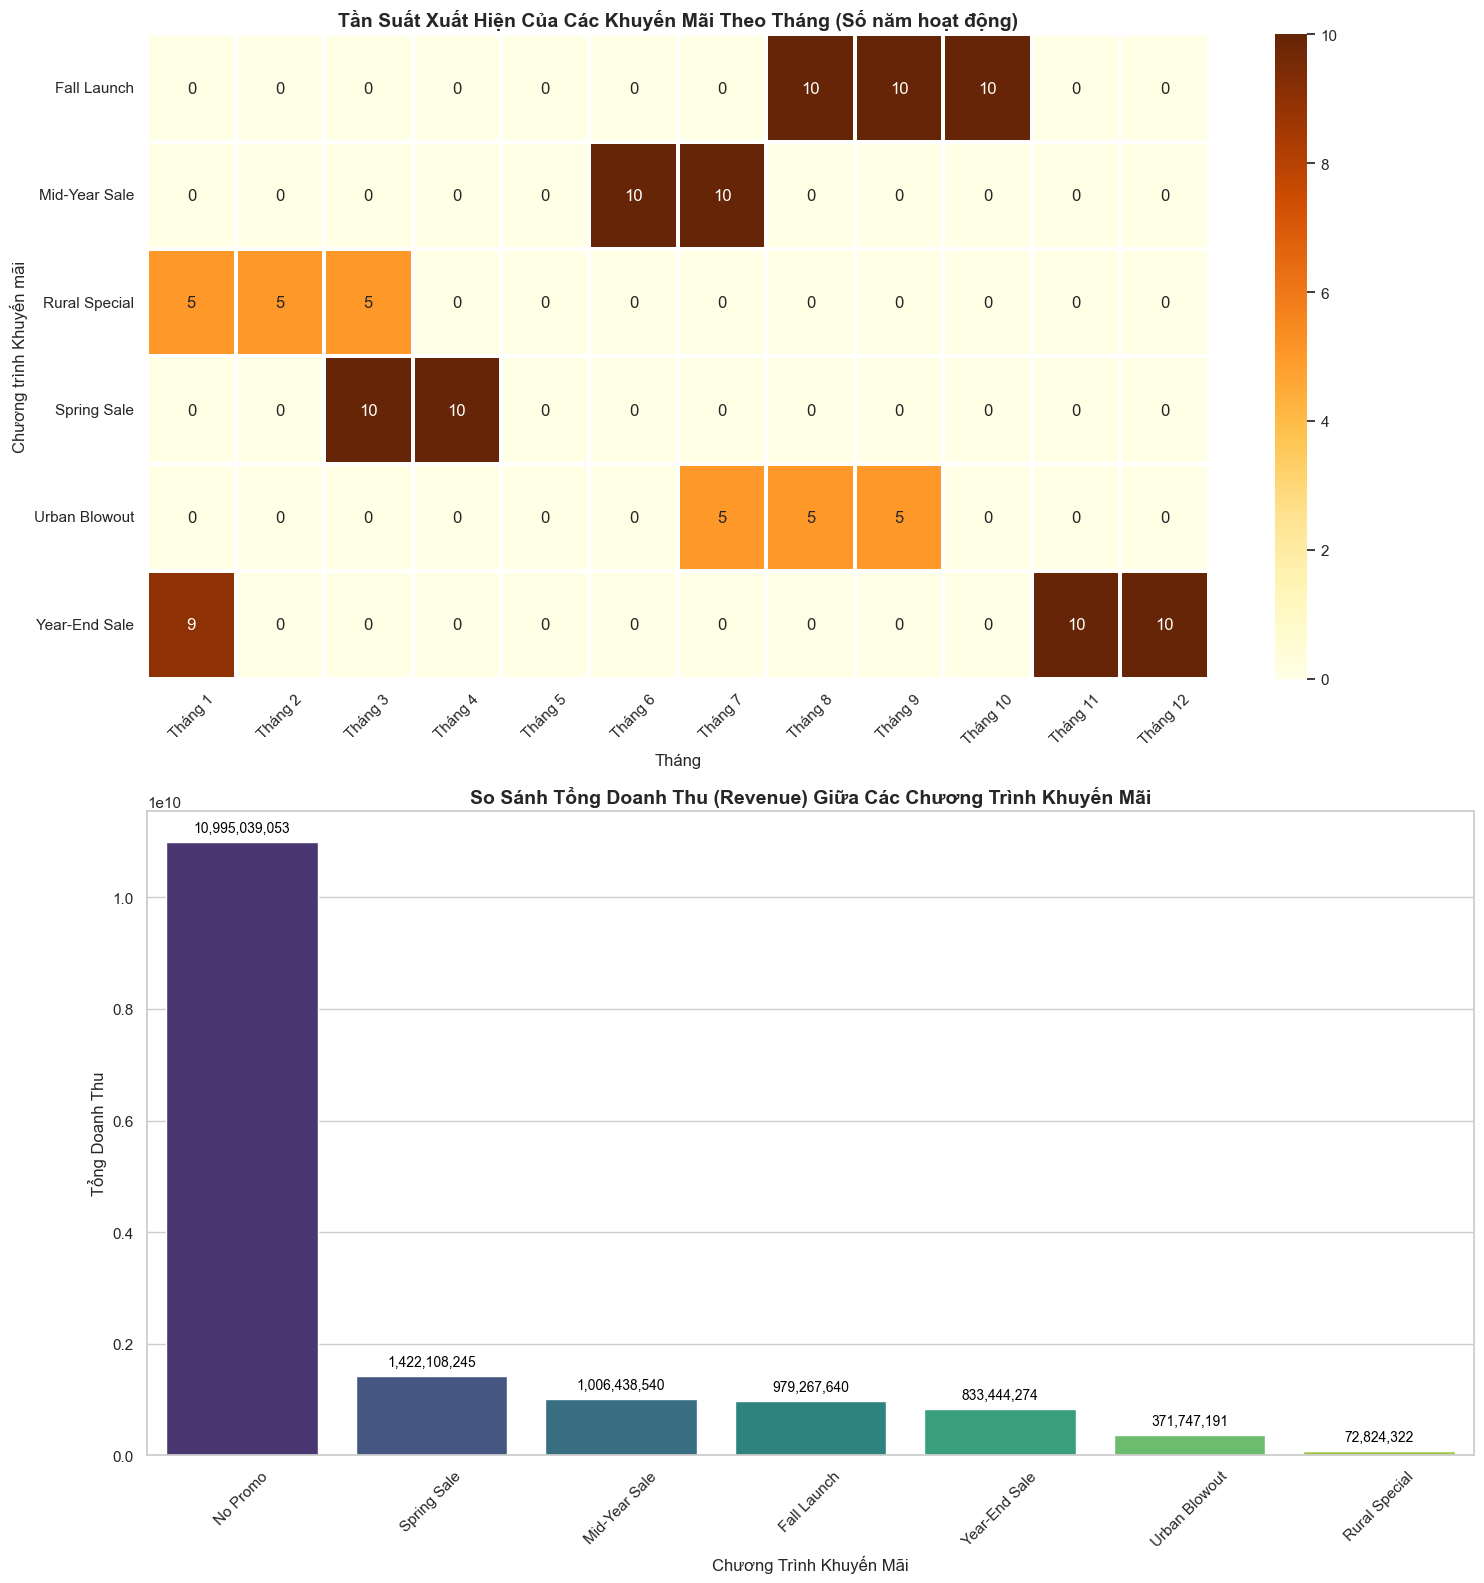

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC DỮ LIỆU
df_promos = pd.read_csv('../dataset/promotions.csv')
df_orders = pd.read_csv('../dataset/order_items.csv')
df_products = pd.read_csv('../dataset/products.csv')

# 2. XỬ LÝ DỮ LIỆU
# --- Tính Doanh thu ---
df_orders['revenue'] = (df_orders['quantity'] * df_orders['unit_price']) - df_orders['discount_amount']

# --- Xử lý Promo ---
df_orders['promo_id'] = df_orders['promo_id'].astype(str)
df_promos['promo_id'] = df_promos['promo_id'].astype(str)

# Lấy tên khuyến mãi gốc (cắt bỏ năm)
df_promos['base_promo_name'] = df_promos['promo_name'].str.replace(r'\s*\d{4}', '', regex=True).str.strip()

# --- Kết nối Dữ liệu ---
df_merged = pd.merge(df_orders, df_promos[['promo_id', 'base_promo_name']], on='promo_id', how='left')
df_merged['base_promo_name'] = df_merged['base_promo_name'].fillna('No Promo')
df_merged['base_promo_name'] = df_merged['base_promo_name'].replace(['', 'nan'], 'No Promo')

# (Lưu ý: Không bắt buộc phải merge với products.csv nữa nếu biểu đồ 2 không dùng đến category, 
# nhưng tôi vẫn giữ lại ở đây để đảm bảo logic luồng dữ liệu của bạn không bị phá vỡ)
df_merged = pd.merge(df_merged, df_products[['product_id', 'category']], on='product_id', how='left')

# --- Xử lý dữ liệu Lịch trình TẦN SUẤT theo Tháng ---
df_promos['start_date'] = pd.to_datetime(df_promos['start_date'])
df_promos['end_date'] = pd.to_datetime(df_promos['end_date'])

promo_month_years = []
for _, row in df_promos.dropna(subset=['start_date', 'end_date']).iterrows():
    dates = pd.date_range(start=row['start_date'], end=row['end_date'])
    unique_year_months = dates.to_period('M').unique()
    for ym in unique_year_months:
        promo_month_years.append({
            'base_promo_name': row['base_promo_name'], 
            'year': ym.year,
            'month': ym.month
        })

df_pmy = pd.DataFrame(promo_month_years).drop_duplicates()
df_freq = df_pmy.groupby(['base_promo_name', 'month'])['year'].count().reset_index(name='frequency')

pivot_freq = df_freq.pivot(index='base_promo_name', columns='month', values='frequency').fillna(0)
pivot_freq = pivot_freq.reindex(columns=range(1, 13), fill_value=0)
pivot_freq.columns = [f'Tháng {i}' for i in range(1, 13)]


# 3. TRỰC QUAN HÓA (VISUALIZATION)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 16))

# =====================================================================
# BIỂU ĐỒ 1: BẢN ĐỒ NHIỆT THỂ HIỆN TẦN SUẤT XUẤT HIỆN CỦA PROMO
# =====================================================================
ax1 = axes[0]

sns.heatmap(
    pivot_freq, 
    cmap='YlOrBr', 
    annot=True,     
    fmt='g',        
    linewidths=1.5, 
    linecolor='white', 
    ax=ax1
)

ax1.set_title('Tần Suất Xuất Hiện Của Các Khuyến Mãi Theo Tháng (Số năm hoạt động)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Chương trình Khuyến mãi', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# =====================================================================
# BIỂU ĐỒ 2: SO SÁNH TỔNG DOANH THU GIỮA CÁC CHƯƠNG TRÌNH KHUYẾN MÃI
# =====================================================================
ax2 = axes[1]

# Gom nhóm tính tổng doanh thu theo từng tên chương trình khuyến mãi
promo_comparison = df_merged.groupby('base_promo_name')['revenue'].sum().reset_index()

# Sắp xếp giảm dần để dễ so sánh
promo_comparison = promo_comparison.sort_values('revenue', ascending=False)

sns.barplot(
    data=promo_comparison, 
    x='base_promo_name', 
    y='revenue', 
    palette='viridis', 
    ax=ax2
)

# Hiển thị số liệu doanh thu trực tiếp trên đầu mỗi cột
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():,.0f}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', 
                 fontsize=10, color='black', xytext=(0, 5), 
                 textcoords='offset points')

ax2.set_title('So Sánh Tổng Doanh Thu (Revenue) Giữa Các Chương Trình Khuyến Mãi', fontsize=14, fontweight='bold')
ax2.set_xlabel('Chương Tr

# Attempt : Thể hiện quan hệ giữa rev/cogs và các promo
file:

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2015161580.py:9: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../dataset/order_items.csv')


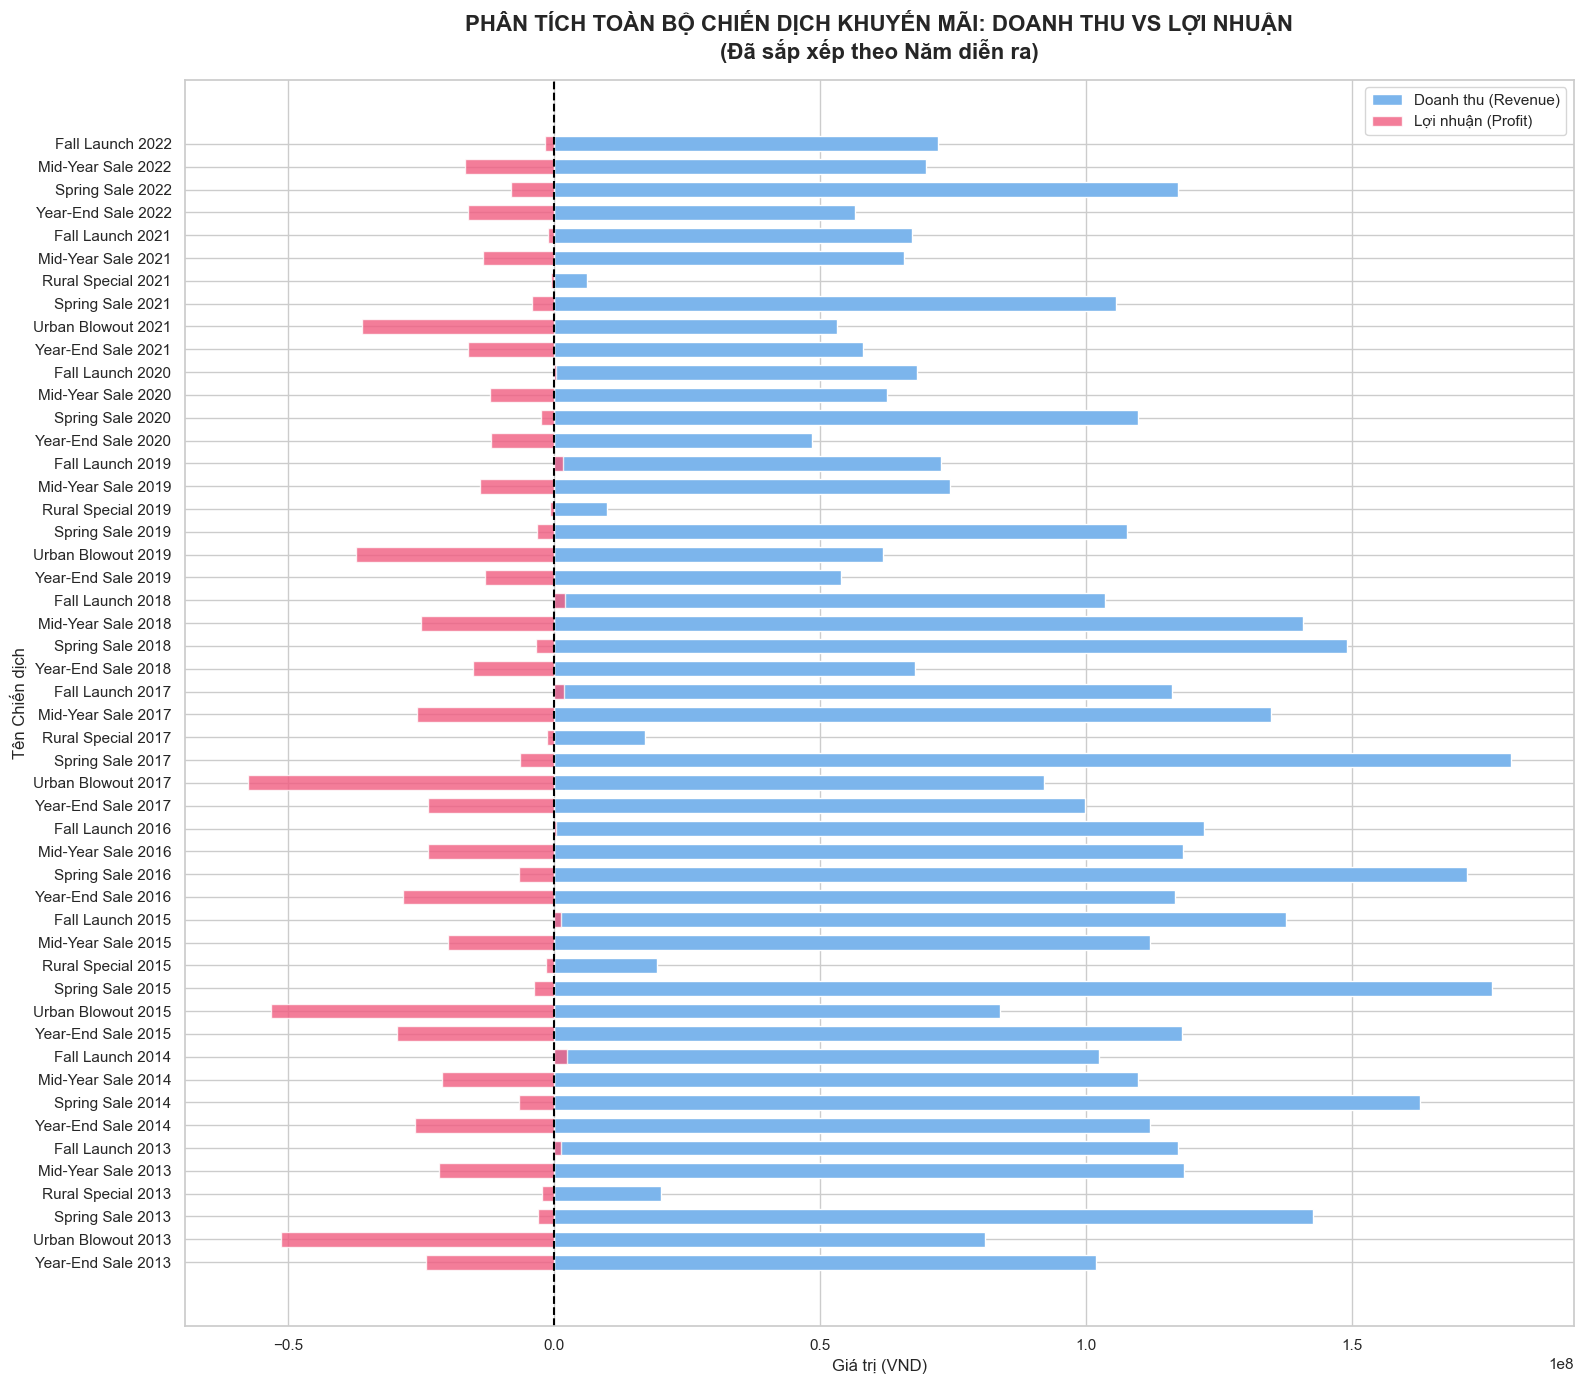

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
df_promos = pd.read_csv('../dataset/promotions.csv')
df_order_items = pd.read_csv('../dataset/order_items.csv')
# Cần products.csv để lấy giá vốn (cogs) tính Lợi nhuận
df_products = pd.read_csv('../dataset/products.csv')

# ==========================================
# 2. XỬ LÝ DỮ LIỆU
# ==========================================
# Lấy ra thông tin 'Năm' từ cột start_date của chiến dịch
df_promos['start_date'] = pd.to_datetime(df_promos['start_date'])
df_promos['year'] = df_promos['start_date'].dt.year

# Xử lý chuẩn hóa ID để merge
df_order_items['promo_id'] = df_order_items['promo_id'].astype(str)
df_promos['promo_id'] = df_promos['promo_id'].astype(str)

# Ghép dữ liệu để lấy Tên Promo, Năm diễn ra và Giá vốn (cogs)
df_merged = pd.merge(df_order_items, df_promos[['promo_id', 'promo_name', 'year']], on='promo_id', how='inner')
df_merged = pd.merge(df_merged, df_products[['product_id', 'cogs']], on='product_id', how='left')

# Tính toán Doanh thu và Lợi nhuận
# Doanh thu = (Số lượng * Đơn giá) - Giảm giá
df_merged['revenue'] = (df_merged['quantity'] * df_merged['unit_price']) - df_merged['discount_amount']
# Giá vốn tổng = Số lượng * Giá vốn từng SP
df_merged['total_cogs'] = df_merged['quantity'] * df_merged['cogs']
# Lợi nhuận = Doanh thu - Giá vốn tổng
df_merged['profit'] = df_merged['revenue'] - df_merged['total_cogs']

# Gom nhóm tổng số liệu theo Tên chiến dịch và Năm
promo_stats = df_merged.groupby(['promo_name', 'year'])[['revenue', 'profit']].sum().reset_index()

# YÊU CẦU CỐT LÕI: SẮP XẾP THEO NĂM
# Sắp xếp giảm dần theo năm (năm mới nhất ở trên cùng), nếu cùng năm thì xếp theo tên theo alphabet
promo_stats = promo_stats.sort_values(by=['year', 'promo_name'], ascending=[False, True]).reset_index(drop=True)


# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 14))

# Cột Doanh thu (Màu xanh, hướng sang phải)
ax.barh(
    y=promo_stats['promo_name'], 
    width=promo_stats['revenue'], 
    color='#7cb5ec', 
    label='Doanh thu (Revenue)', 
    height=0.65
)

# Cột Lợi nhuận (Màu đỏ/hồng, các giá trị âm sẽ tự động lùi về bên trái trục 0)
ax.barh(
    y=promo_stats['promo_name'], 
    width=promo_stats['profit'], 
    color='#f15c80', 
    label='Lợi nhuận (Profit)', 
    alpha=0.8, 
    height=0.65
)

# Vẽ một đường ranh giới đen đứt nét tại mốc 0 (Zero-line) để dễ quan sát lỗ/lãi
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

# Căn chỉnh tiêu đề và nhãn
ax.set_title('PHÂN TÍCH TOÀN BỘ CHIẾN DỊCH KHUYẾN MÃI: DOANH THU VS LỢI NHUẬN\n(Đã sắp xếp theo Năm diễn ra)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Giá trị (VND)', fontsize=12)
ax.set_ylabel('Tên Chiến dịch', fontsize=12)

# Hiển thị chú thích
ax.legend(loc='upper right', frameon=True)

# Lật ngược trục Y để các dòng đầu tiên (năm mới nhất) nằm ở trên cùng của biểu đồ
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Attempt: Thể hiện quan hệ giữa promo với sales

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/7699339.py:9: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../dataset/order_items.csv')


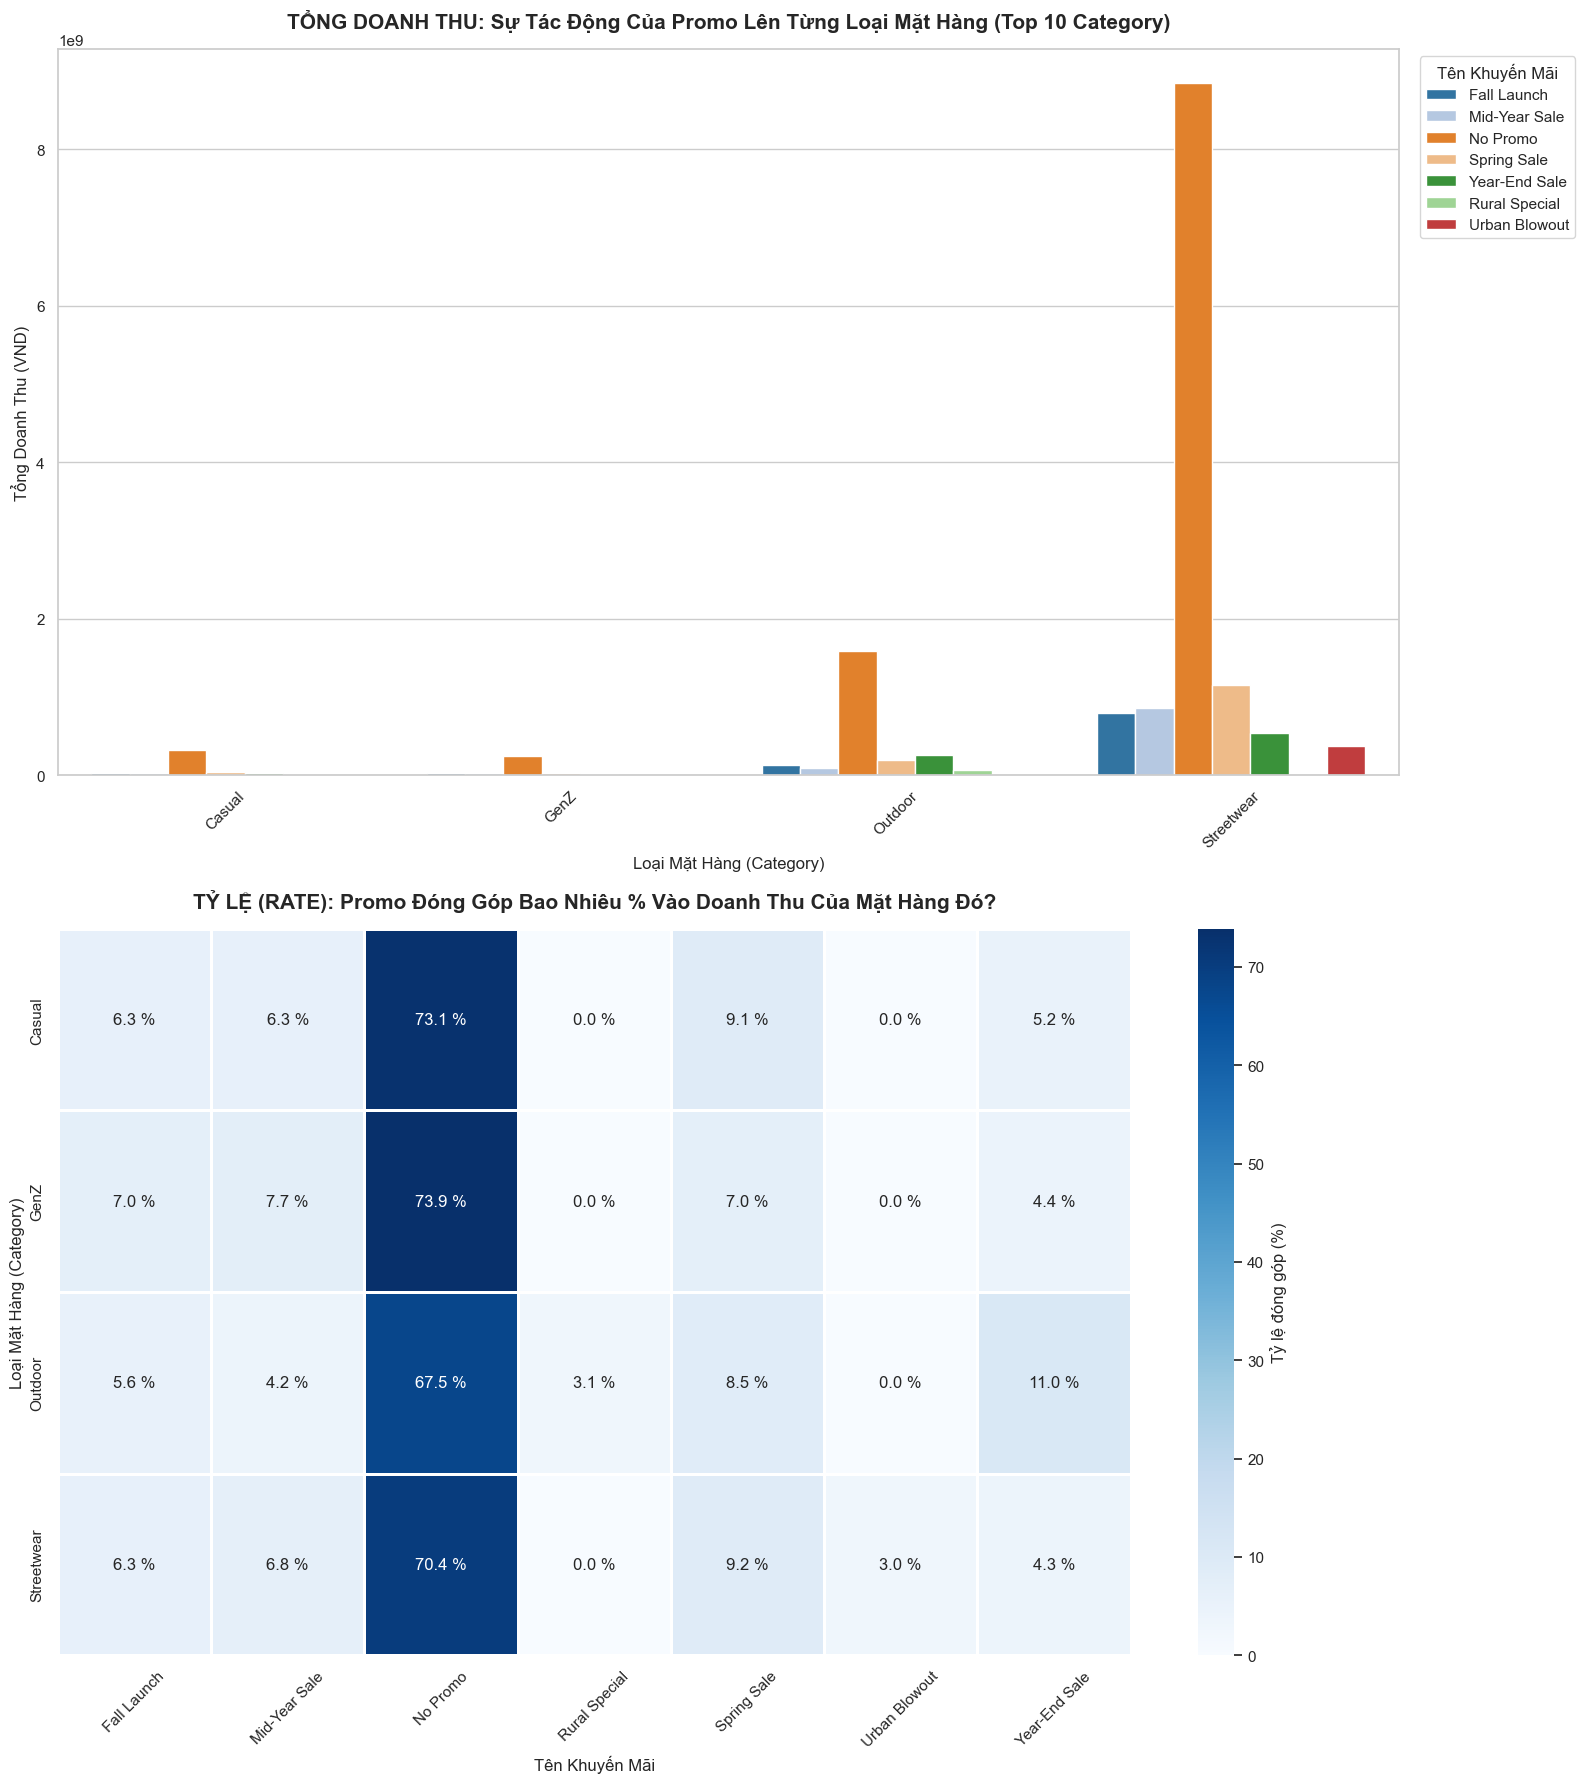

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC DỮ LIỆU TỪ ../dataset/
# ==========================================
df_promos = pd.read_csv('../dataset/promotions.csv')
df_order_items = pd.read_csv('../dataset/order_items.csv')
df_products = pd.read_csv('../dataset/products.csv')

# ==========================================
# 2. XỬ LÝ DỮ LIỆU 
# ==========================================
# Tính doanh thu từng dòng
df_order_items['revenue'] = (df_order_items['quantity'] * df_order_items['unit_price']) - df_order_items['discount_amount']

# Xử lý ID và Tên Promo (gộp năm)
df_order_items['promo_id'] = df_order_items['promo_id'].astype(str).replace(['nan', 'None'], 'No Promo')
df_promos['promo_id'] = df_promos['promo_id'].astype(str)
df_promos['base_promo_name'] = df_promos['promo_name'].str.replace(r'\s*\d{4}', '', regex=True).str.strip()

# Ghép bảng để lấy thông tin Loại mặt hàng (Category) và Tên Promo
df_merged = pd.merge(df_order_items, df_products[['product_id', 'category']], on='product_id', how='left')
df_merged = pd.merge(df_merged, df_promos[['promo_id', 'base_promo_name']], on='promo_id', how='left')
df_merged['base_promo_name'] = df_merged['base_promo_name'].fillna('No Promo')

# --- TÍNH TOÁN TOTAL & RATE ---
# 2.1. Tính tổng doanh thu theo (Loại mặt hàng + Promo)
cat_promo_stats = df_merged.groupby(['category', 'base_promo_name'])['revenue'].sum().reset_index()

# 2.2. Tính tổng doanh thu của MỖI LOẠI MẶT HÀNG (Dùng làm mẫu số tính Rate)
cat_totals = df_merged.groupby('category')['revenue'].sum().reset_index(name='category_total_revenue')

# 2.3. Ghép lại để tính Rate (% đóng góp của Promo vào mặt hàng đó)
cat_promo_stats = pd.merge(cat_promo_stats, cat_totals, on='category', how='left')
cat_promo_stats['contribution_rate'] = (cat_promo_stats['revenue'] / cat_promo_stats['category_total_revenue']) * 100

# Lọc Top 10 Loại mặt hàng có doanh thu cao nhất để biểu đồ không bị rối mắt
top_categories = cat_totals.sort_values('category_total_revenue', ascending=False).head(10)['category']
cat_promo_stats_top = cat_promo_stats[cat_promo_stats['category'].isin(top_categories)]

# Tạo bảng Pivot (Ma trận) cho Heatmap tỷ lệ Rate
pivot_rate_top = cat_promo_stats_top.pivot(index='category', columns='base_promo_name', values='contribution_rate').fillna(0)

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 18))

# -------------------------------------------------------------------
# BIỂU ĐỒ 1: TỔNG DOANH THU THEO LOẠI MẶT HÀNG VÀ PROMO (TOTAL)
# -------------------------------------------------------------------
ax1 = axes[0]
sns.barplot(
    data=cat_promo_stats_top, 
    x='category', 
    y='revenue', 
    hue='base_promo_name', 
    palette='tab20', 
    ax=ax1
)
ax1.set_title('TỔNG DOANH THU: Sự Tác Động Của Promo Lên Từng Loại Mặt Hàng (Top 10 Category)', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Tổng Doanh Thu (VND)', fontsize=12)
ax1.set_xlabel('Loại Mặt Hàng (Category)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Tên Khuyến Mãi', bbox_to_anchor=(1.01, 1), loc='upper left')

# -------------------------------------------------------------------
# BIỂU ĐỒ 2: TỶ LỆ ĐÓNG GÓP CỦA PROMO VÀO DOANH THU MẶT HÀNG (RATE %)
# -------------------------------------------------------------------
ax2 = axes[1]
# Dùng heatmap màu xanh, hiển thị số kèm dấu %
sns.heatmap(
    pivot_rate_top, 
    annot=True, 
    fmt='.1f', 
    cmap='Blues', 
    linewidths=1, 
    linecolor='white',
    cbar_kws={'label': 'Tỷ lệ đóng góp (%)'},
    ax=ax2
)

# Thêm ký hiệu % vào các con số trong Heatmap cho trực quan
for t in ax2.texts: t.set_text(t.get_text() + " %")

ax2.set_title('TỶ LỆ (RATE): Promo Đóng Góp Bao Nhiêu % Vào Doanh Thu Của Mặt Hàng Đó?', fontsize=15, fontweight='bold', pad=15)
ax2.set_ylabel('Loại Mặt Hàng (Category)', fontsize=12)
ax2.set_xlabel('Tên Khuyến Mãi', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Attempt 5: Thể hiện returns data đối với các loại mặt hàng (cả rate và total)
files: returns.csv + products.csv + customers.csv + order_items.csv

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2687844893.py:13: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../dataset/order_items.csv')
/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2687844893.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_stats.sort_values('total_returned', ascending=False),
/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2687844893.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_stats.sort_values('return_rate_pct', ascending=False),


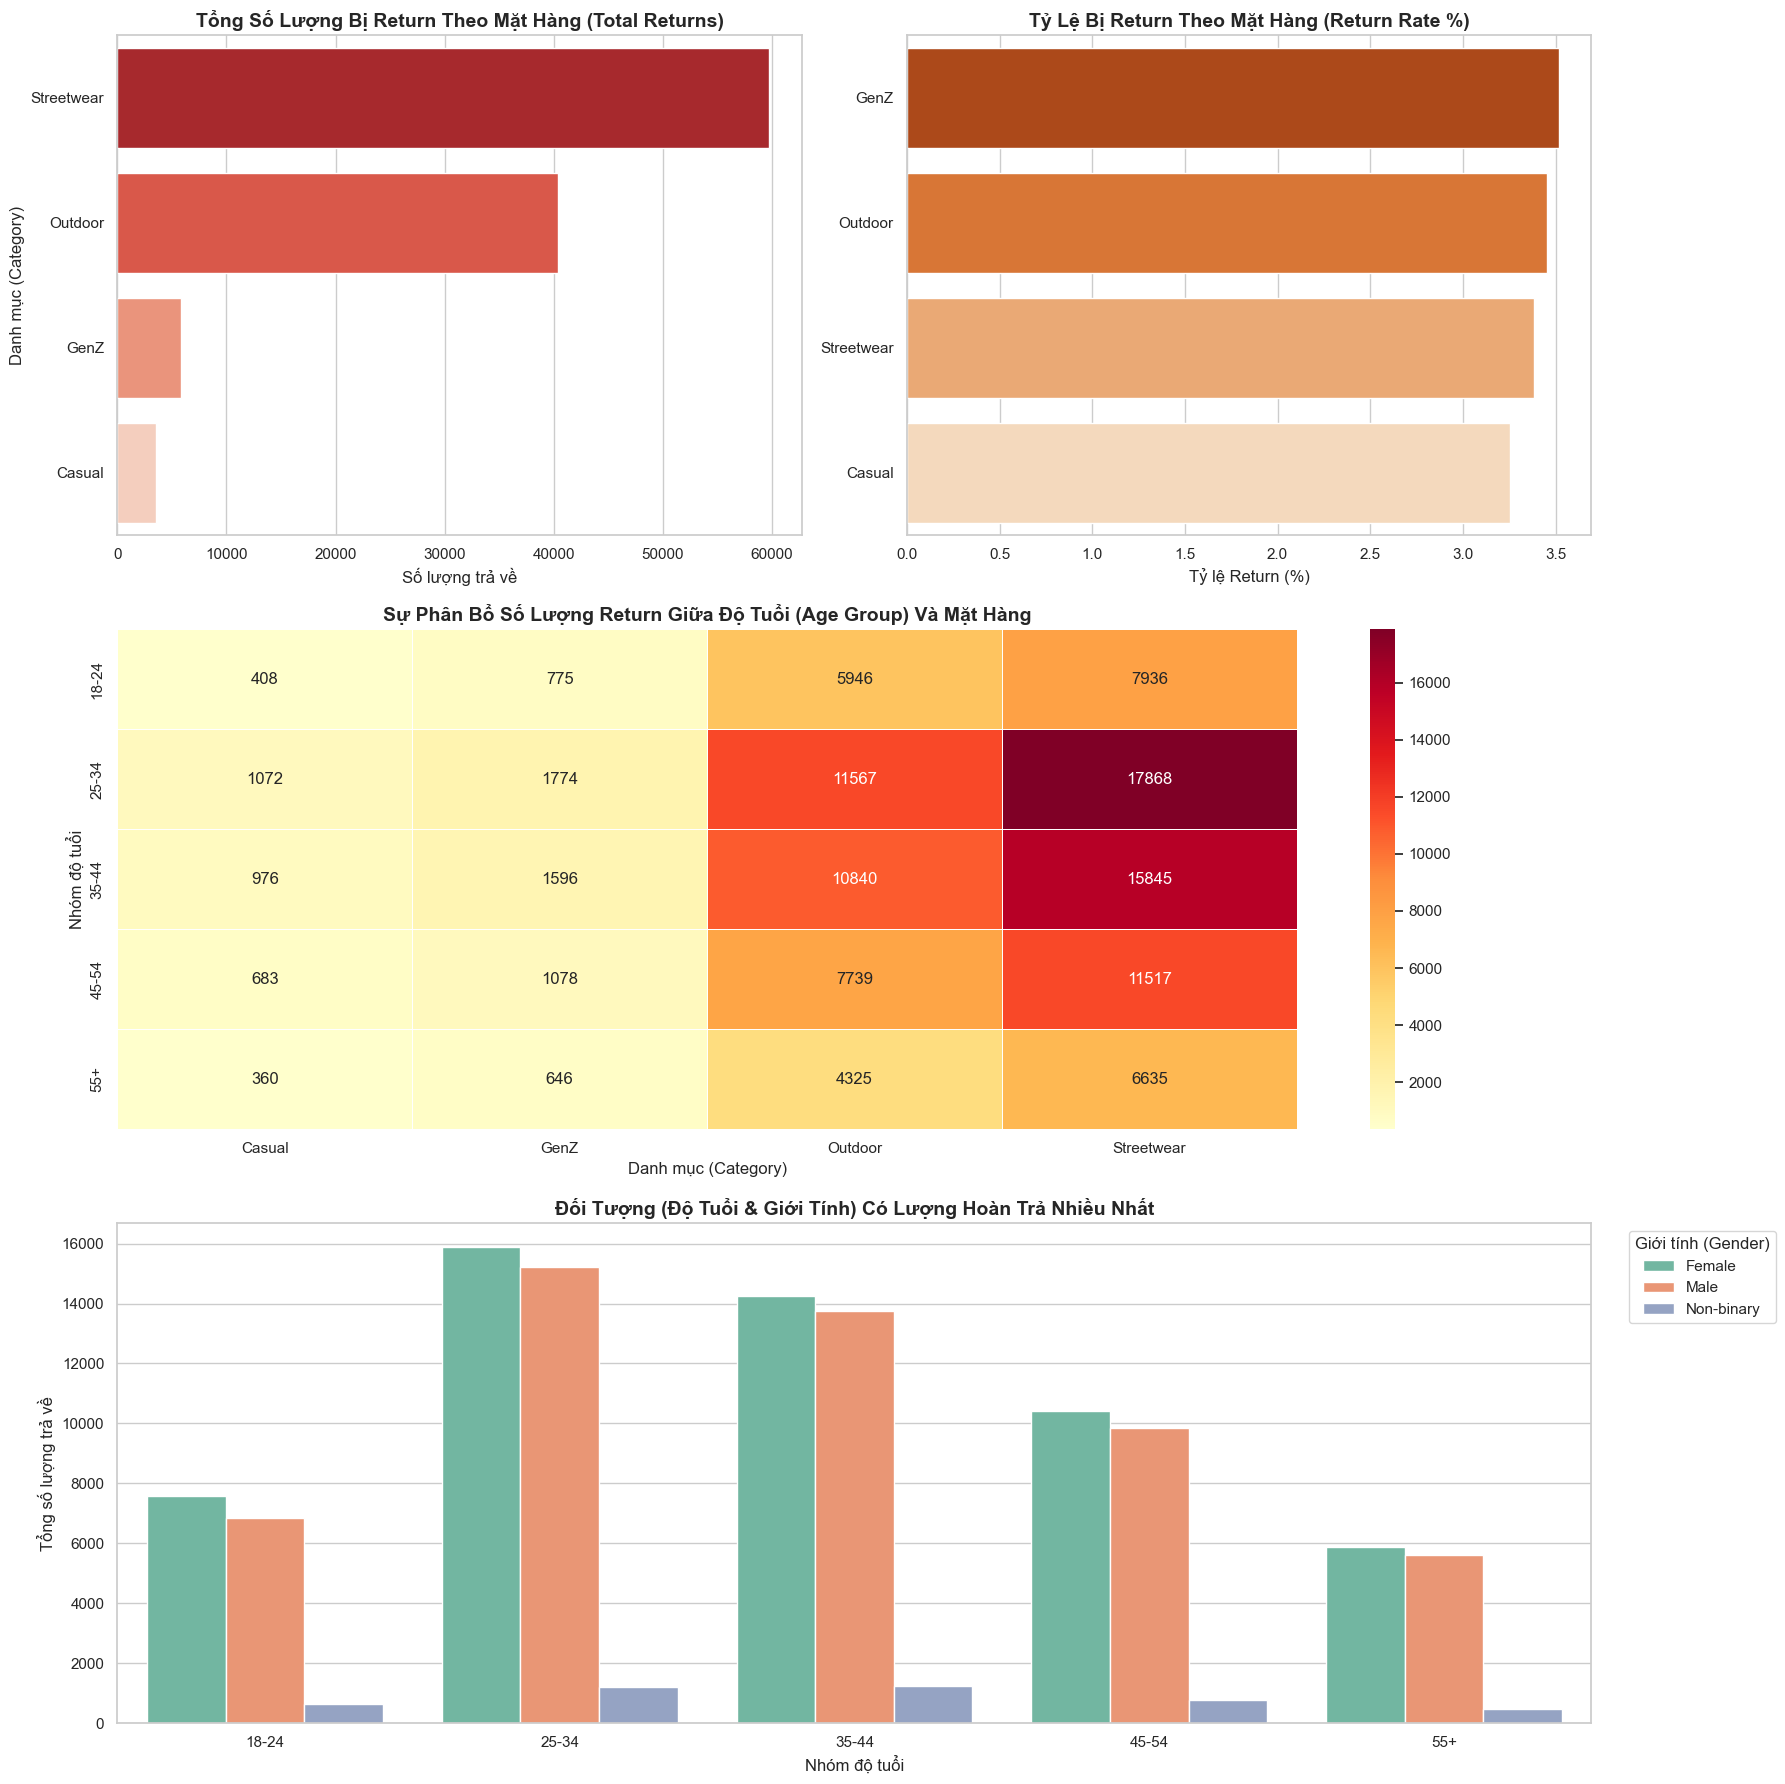

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC DỮ LIỆU
# ==========================================
df_returns = pd.read_csv('../dataset/returns.csv')
df_products = pd.read_csv('../dataset/products.csv')
df_customers = pd.read_csv('../dataset/customers.csv')

# Cần order_items để tính Return Rate (so sánh lượng trả / lượng bán)
df_order_items = pd.read_csv('../dataset/order_items.csv')

# Cần orders để lấy customer_id cho mỗi order_id bị return
df_orders = pd.read_csv('../dataset/orders.csv')

# ==========================================
# 2. XỬ LÝ DỮ LIỆU
# ==========================================
# Gộp Category từ bảng Products vào Returns và Order Items
df_ret_prod = pd.merge(df_returns, df_products[['product_id', 'category']], on='product_id', how='left')
df_oi_prod = pd.merge(df_order_items, df_products[['product_id', 'category']], on='product_id', how='left')

# --- Phân tích 1: Loại mặt hàng bị return nhiều nhất (Rate và Total) ---
# Lượng bán ra theo category
cat_sold = df_oi_prod.groupby('category')['quantity'].sum().reset_index(name='total_sold')
# Lượng trả về theo category
cat_ret = df_ret_prod.groupby('category')['return_quantity'].sum().reset_index(name='total_returned')

cat_stats = pd.merge(cat_ret, cat_sold, on='category', how='left').fillna(0)
cat_stats['return_rate_pct'] = (cat_stats['total_returned'] / cat_stats['total_sold']) * 100

# --- Phân tích 2 & 3: Đối tượng return nhiều nhất & Mặt hàng theo đối tượng ---
# Kết nối Returns -> Orders -> Customers
df_ret_cust = pd.merge(df_ret_prod, df_orders[['order_id', 'customer_id']], on='order_id', how='left')
df_ret_full = pd.merge(df_ret_cust, df_customers[['customer_id', 'age_group', 'gender']], on='customer_id', how='left')

# Loại bỏ các dòng thiếu thông tin age_group (nếu có)
df_ret_full = df_ret_full.dropna(subset=['age_group', 'category'])

# Ma trận: Độ tuổi vs Loại mặt hàng
pivot_age_cat = df_ret_full.pivot_table(index='age_group', columns='category', values='return_quantity', aggfunc='sum', fill_value=0)

# Tổng trả hàng theo Đối tượng (Độ tuổi & Giới tính)
demo_ret = df_ret_full.groupby(['age_group', 'gender'])['return_quantity'].sum().reset_index()


# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 18))

# Chia lưới hiển thị cho các biểu đồ
gs = fig.add_gridspec(3, 2)

# --- Biểu đồ 1a: Tổng số lượng hàng bị Return theo Category ---
ax1 = fig.add_subplot(gs[0, 0])
sns.barplot(data=cat_stats.sort_values('total_returned', ascending=False), 
            x='total_returned', y='category', palette='Reds_r', ax=ax1)
ax1.set_title('Tổng Số Lượng Bị Return Theo Mặt Hàng (Total Returns)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Số lượng trả về', fontsize=12)
ax1.set_ylabel('Danh mục (Category)', fontsize=12)

# --- Biểu đồ 1b: Tỷ lệ Return theo Category (Return Rate %) ---
ax2 = fig.add_subplot(gs[0, 1])
sns.barplot(data=cat_stats.sort_values('return_rate_pct', ascending=False), 
            x='return_rate_pct', y='category', palette='Oranges_r', ax=ax2)
ax2.set_title('Tỷ Lệ Bị Return Theo Mặt Hàng (Return Rate %)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tỷ lệ Return (%)', fontsize=12)
ax2.set_ylabel('')

# --- Biểu đồ 2: Mặt hàng được return nhiều nhất theo Đối tượng (Heatmap) ---
ax3 = fig.add_subplot(gs[1, :])
sns.heatmap(pivot_age_cat, cmap='YlOrRd', annot=True, fmt='g', linewidths=.5, ax=ax3)
ax3.set_title('Sự Phân Bổ Số Lượng Return Giữa Độ Tuổi (Age Group) Và Mặt Hàng', fontsize=14, fontweight='bold')
ax3.set_xlabel('Danh mục (Category)', fontsize=12)
ax3.set_ylabel('Nhóm độ tuổi', fontsize=12)

# --- Biểu đồ 3: Đối tượng nào return nhiều nhất ---
ax4 = fig.add_subplot(gs[2, :])
sns.barplot(data=demo_ret, x='age_group', y='return_quantity', hue='gender', palette='Set2', ax=ax4)
ax4.set_title('Đối Tượng (Độ Tuổi & Giới Tính) Có Lượng Hoàn Trả Nhiều Nhất', fontsize=14, fontweight='bold')
ax4.set_xlabel('Nhóm độ tuổi', fontsize=12)
ax4.set_ylabel('Tổng số lượng trả về', fontsize=12)
ax4.legend(title='Giới tính (Gender)', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Attempt: Đánh giá inventory ( Inventory health )

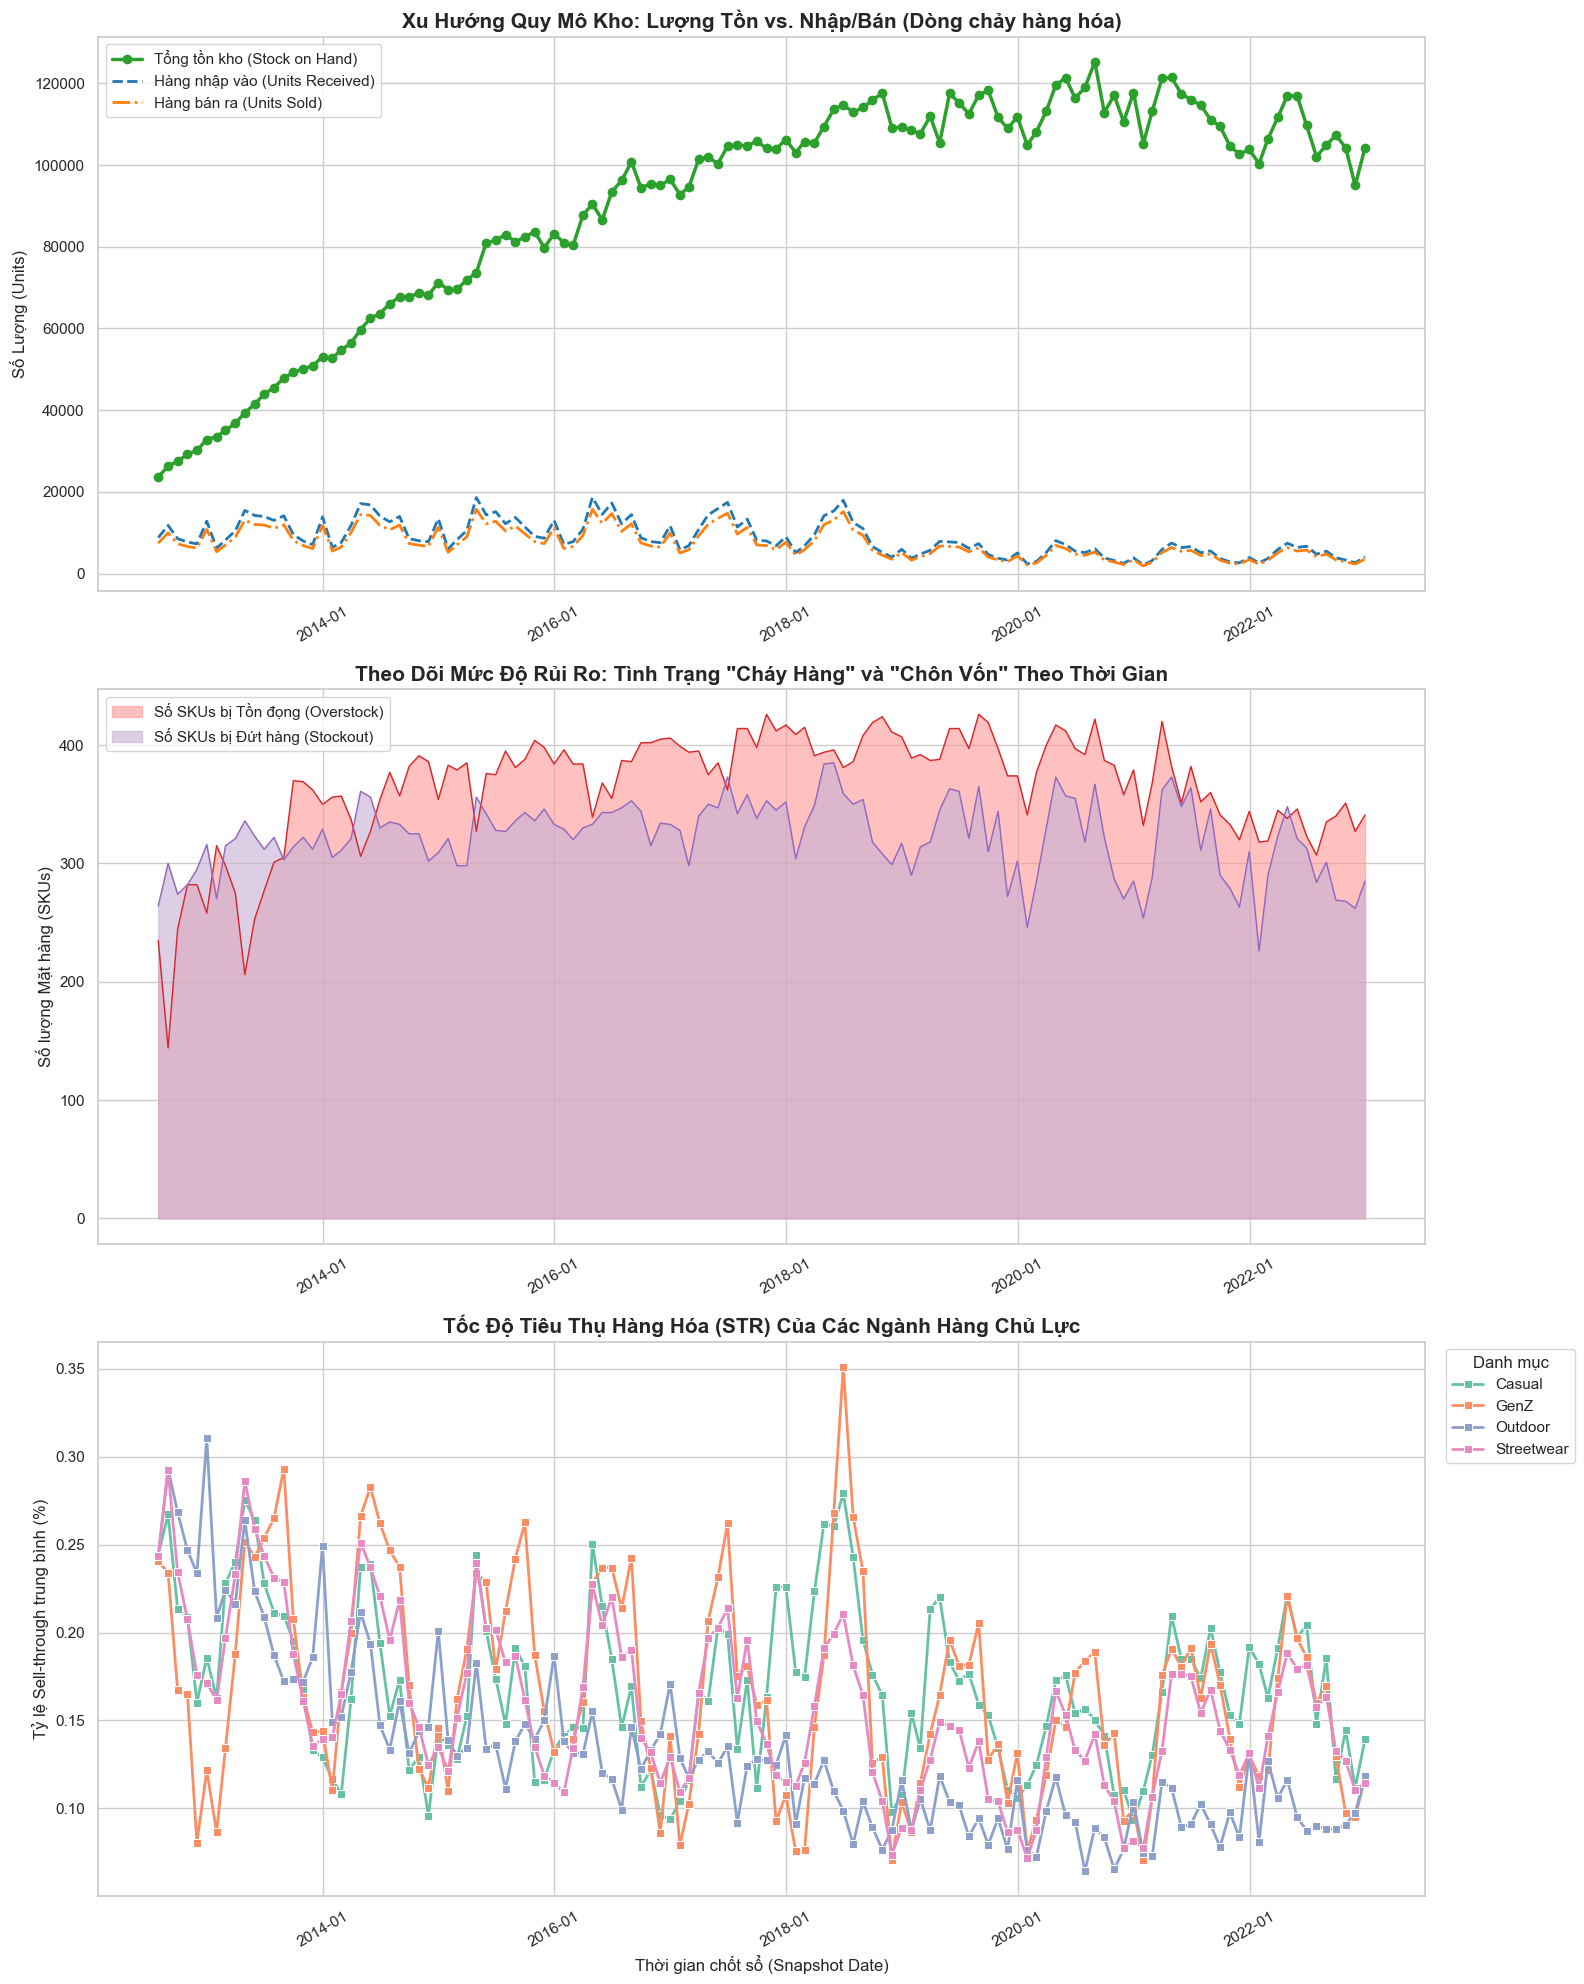

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_inv = pd.read_csv('../dataset/inventory.csv')

# Chuyển đổi định dạng ngày tháng và sắp xếp
df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
df_inv = df_inv.sort_values('snapshot_date')

# Tạo cột Năm-Tháng (YYYY-MM) để dễ dàng gom nhóm theo tháng nếu dữ liệu theo ngày quá nhiễu
df_inv['year_month'] = df_inv['snapshot_date'].dt.to_period('M')

# ==========================================
# 2. XỬ LÝ DỮ LIỆU CHUỖI THỜI GIAN (TIME-SERIES)
# ==========================================
# Tổng hợp Dòng chảy Hàng hóa (Lượng tồn, Lượng nhập, Lượng bán) theo từng mốc thời gian
flow_trend = df_inv.groupby('snapshot_date').agg(
    total_stock=('stock_on_hand', 'sum'),
    total_received=('units_received', 'sum'),
    total_sold=('units_sold', 'sum')
).reset_index()

# Tổng hợp Số lượng mã hàng (SKUs) bị rủi ro (Stockout/Overstock) qua từng kỳ
risk_trend = df_inv.groupby('snapshot_date').agg(
    stockout_count=('stockout_flag', 'sum'), # Vì flag là 1/0 nên sum() = đếm số lượng
    overstock_count=('overstock_flag', 'sum')
).reset_index()

# Đánh giá hiệu suất: Tốc độ bán (Sell-through rate) trung bình theo Category qua thời gian
# Lấy Top 4 Category có lượng tồn kho lớn nhất để tránh biểu đồ quá rối
top_cats = df_inv.groupby('category')['stock_on_hand'].sum().nlargest(4).index
eff_trend = df_inv[df_inv['category'].isin(top_cats)].groupby(['snapshot_date', 'category'])['sell_through_rate'].mean().reset_index()

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZATION)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 20))

# -------------------------------------------------------------------
# BIỂU ĐỒ 1: BIẾN ĐỘNG QUY MÔ TỒN KHO VÀ DÒNG CHẢY HÀNG HÓA
# -------------------------------------------------------------------
ax1 = axes[0]
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_stock'], label='Tổng tồn kho (Stock on Hand)', color='#2ca02c', linewidth=2.5, marker='o')
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_received'], label='Hàng nhập vào (Units Received)', color='#1f77b4', linestyle='--', linewidth=2)
ax1.plot(flow_trend['snapshot_date'], flow_trend['total_sold'], label='Hàng bán ra (Units Sold)', color='#ff7f0e', linestyle='-.', linewidth=2)

ax1.set_title('Xu Hướng Quy Mô Kho: Lượng Tồn vs. Nhập/Bán (Dòng chảy hàng hóa)', fontsize=15, fontweight='bold')
ax1.set_ylabel('Số Lượng (Units)', fontsize=12)
ax1.legend(loc='upper left')

# -------------------------------------------------------------------
# BIỂU ĐỒ 2: THEO DÕI RỦI RO (THIẾU HÀNG / TỒN ĐỌNG) QUA CÁC KỲ
# -------------------------------------------------------------------
ax2 = axes[1]
# Dùng biểu đồ miền (Area chart) để thấy rõ khối lượng rủi ro
ax2.fill_between(risk_trend['snapshot_date'], risk_trend['overstock_count'], color='#ff9896', alpha=0.6, label='Số SKUs bị Tồn đọng (Overstock)')
ax2.fill_between(risk_trend['snapshot_date'], risk_trend['stockout_count'], color='#c5b0d5', alpha=0.6, label='Số SKUs bị Đứt hàng (Stockout)')
ax2.plot(risk_trend['snapshot_date'], risk_trend['overstock_count'], color='#d62728', linewidth=1)
ax2.plot(risk_trend['snapshot_date'], risk_trend['stockout_count'], color='#9467bd', linewidth=1)

ax2.set_title('Theo Dõi Mức Độ Rủi Ro: Tình Trạng "Cháy Hàng" và "Chôn Vốn" Theo Thời Gian', fontsize=15, fontweight='bold')
ax2.set_ylabel('Số lượng Mặt hàng (SKUs)', fontsize=12)
ax2.legend(loc='upper left')

# -------------------------------------------------------------------
# BIỂU ĐỒ 3: HIỆU SUẤT ĐẨY HÀNG (SELL-THROUGH RATE) THEO DANH MỤC
# -------------------------------------------------------------------
ax3 = axes[2]
sns.lineplot(
    data=eff_trend, 
    x='snapshot_date', 
    y='sell_through_rate', 
    hue='category', 
    palette='Set2', 
    linewidth=2, 
    marker='s',
    ax=ax3
)

ax3.set_title('Tốc Độ Tiêu Thụ Hàng Hóa (STR) Của Các Ngành Hàng Chủ Lực', fontsize=15, fontweight='bold')
ax3.set_ylabel('Tỷ lệ Sell-through trung bình (%)', fontsize=12)
ax3.set_xlabel('Thời gian chốt sổ (Snapshot Date)', fontsize=12)
ax3.legend(title='Danh mục', bbox_to_anchor=(1.01, 1), loc='upper left')

# Định dạng chung cho trục X (Thời gian) của cả 3 biểu đồ
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Inventory tồn theo mặt hàng

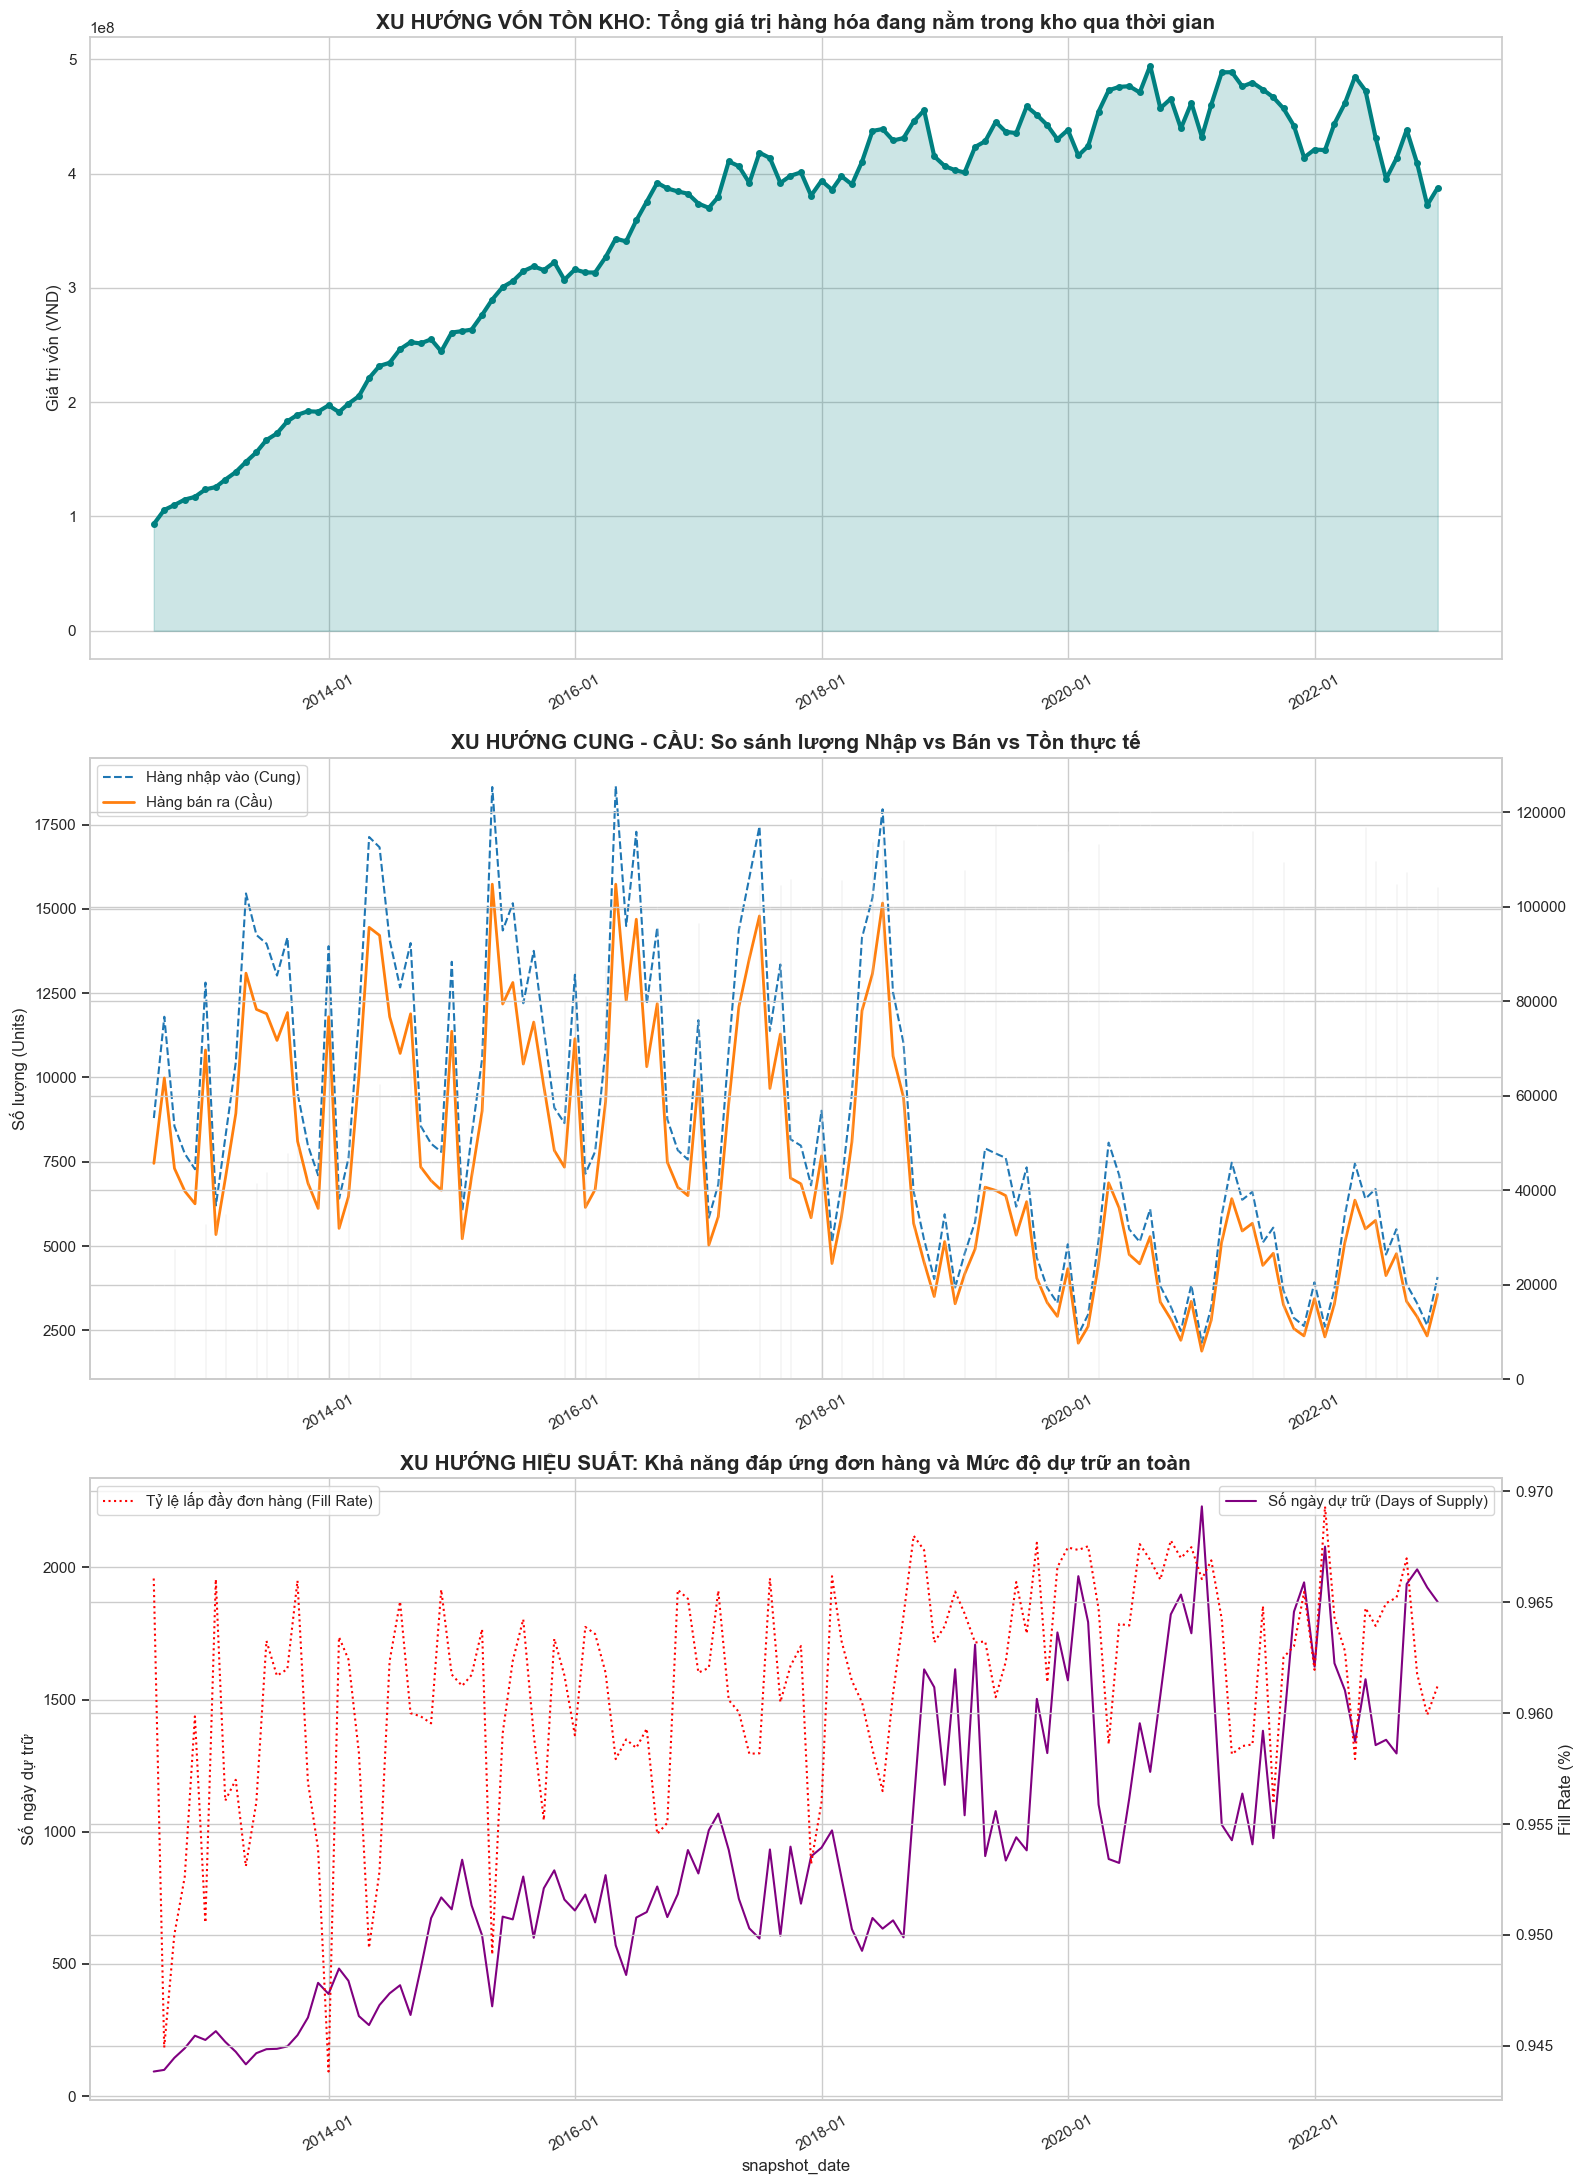

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. ĐỌC DỮ LIỆU
df_inv = pd.read_csv('../dataset/inventory.csv')
df_prod = pd.read_csv('../dataset/products.csv')

# 2. XỬ LÝ DỮ LIỆU CHUỖI THỜI GIAN
df_inv['snapshot_date'] = pd.to_datetime(df_inv['snapshot_date'])
df_inv = df_inv.sort_values('snapshot_date')

# Ghép với bảng products để lấy giá vốn (cogs) tính giá trị tiền tồn kho
df_trend = pd.merge(df_inv, df_prod[['product_id', 'cogs']], on='product_id', how='left')
df_trend['total_inventory_value'] = df_trend['stock_on_hand'] * df_trend['cogs']

# Gom nhóm theo thời gian (Snapshot)
time_series = df_trend.groupby('snapshot_date').agg({
    'total_inventory_value': 'sum',
    'stock_on_hand': 'sum',
    'units_sold': 'sum',
    'units_received': 'sum',
    'days_of_supply': 'mean',
    'fill_rate': 'mean'
}).reset_index()

# 3. TRỰC QUAN HÓA XU HƯỚNG
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(16, 22))

# --- Biểu đồ 1: Xu hướng Giá trị vốn tồn kho (Tài chính) ---
ax1 = axes[0]
ax1.fill_between(time_series['snapshot_date'], time_series['total_inventory_value'], color='teal', alpha=0.2)
ax1.plot(time_series['snapshot_date'], time_series['total_inventory_value'], color='teal', linewidth=3, marker='o', markersize=4)
ax1.set_title('XU HƯỚNG VỐN TỒN KHO: Tổng giá trị hàng hóa đang nằm trong kho qua thời gian', fontsize=15, fontweight='bold')
ax1.set_ylabel('Giá trị vốn (VND)', fontsize=12)

# --- Biểu đồ 2: Cân bằng Cung - Cầu (Inventory Health) ---
ax2 = axes[1]
ax2.plot(time_series['snapshot_date'], time_series['units_received'], label='Hàng nhập vào (Cung)', color='#1f77b4', linestyle='--')
ax2.plot(time_series['snapshot_date'], time_series['units_sold'], label='Hàng bán ra (Cầu)', color='#ff7f0e', linewidth=2)
# Tạo trục Y phụ cho Stock on Hand
ax2_twin = ax2.twinx()
ax2_twin.bar(time_series['snapshot_date'], time_series['stock_on_hand'], alpha=0.15, color='grey', label='Tổng lượng tồn (Units)')

ax2.set_title('XU HƯỚNG CUNG - CẦU: So sánh lượng Nhập vs Bán vs Tồn thực tế', fontsize=15, fontweight='bold')
ax2.set_ylabel('Số lượng (Units)', fontsize=12)
ax2.legend(loc='upper left')

# --- Biểu đồ 3: Hiệu suất vận hành (Days of Supply & Fill Rate) ---
ax3 = axes[2]
ax3_twin = ax3.twinx()
sns.lineplot(data=time_series, x='snapshot_date', y='days_of_supply', ax=ax3, color='purple', label='Số ngày dự trữ (Days of Supply)')
sns.lineplot(data=time_series, x='snapshot_date', y='fill_rate', ax=ax3_twin, color='red', label='Tỷ lệ lấp đầy đơn hàng (Fill Rate)', linestyle=':')

ax3.set_title('XU HƯỚNG HIỆU SUẤT: Khả năng đáp ứng đơn hàng và Mức độ dự trữ an toàn', fontsize=15, fontweight='bold')
ax3.set_ylabel('Số ngày dự trữ', fontsize=12)
ax3_twin.set_ylabel('Fill Rate (%)', fontsize=12)

# Định dạng thời gian trục X
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Giải mã tính mùa vụ

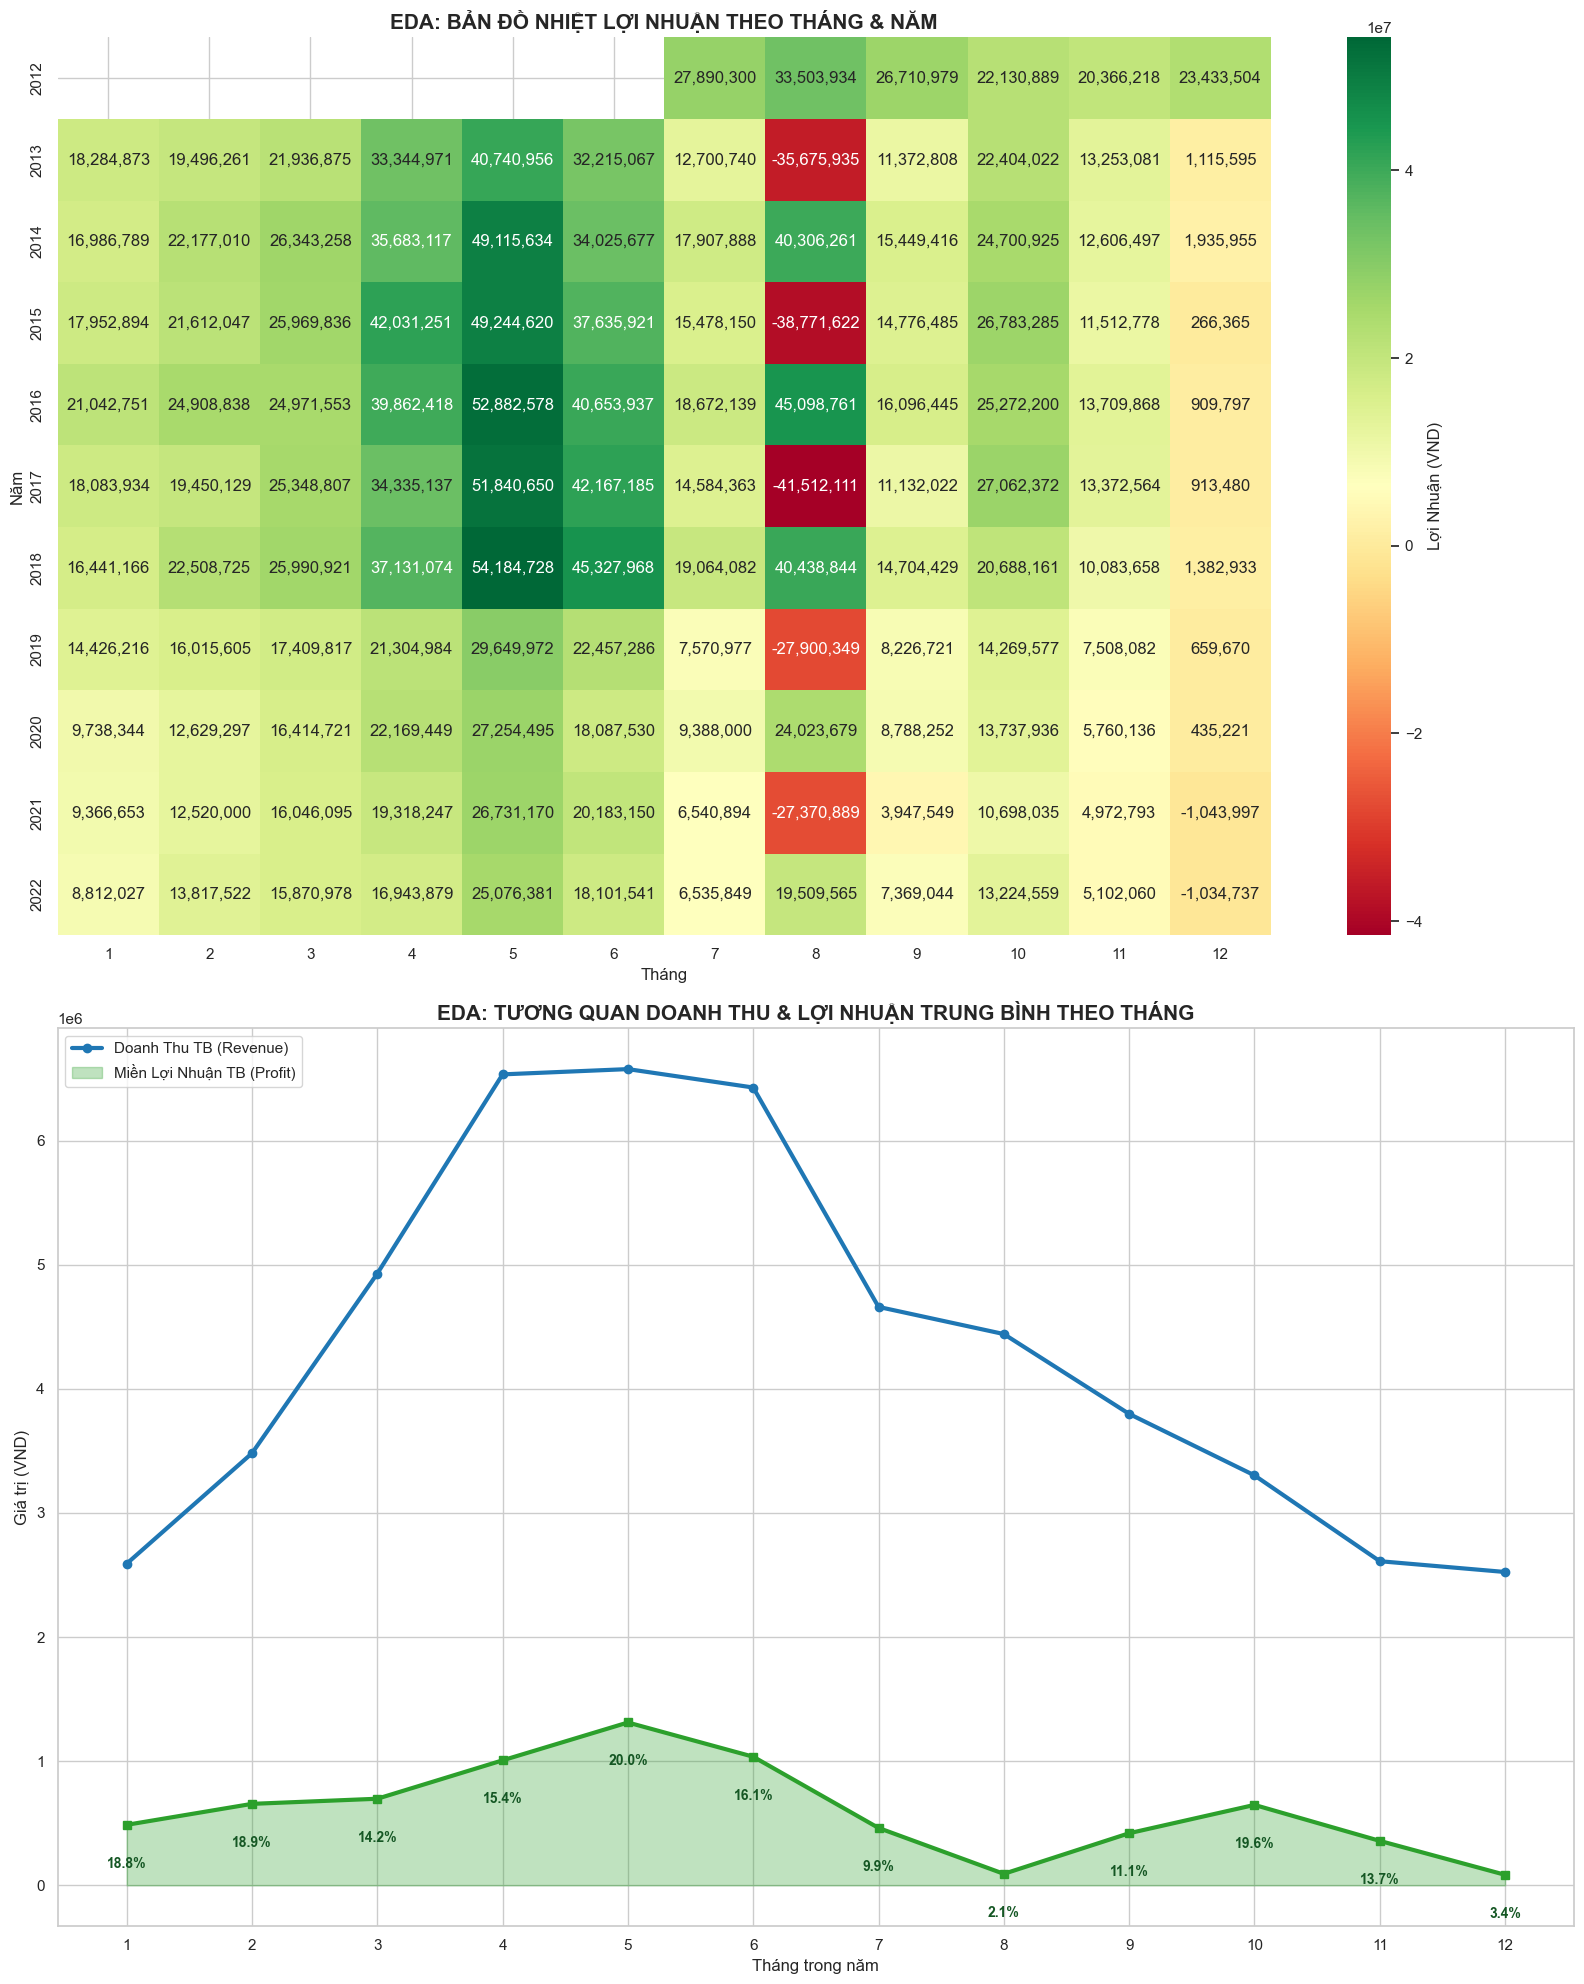

--- CHÌA KHÓA LỢI NHUẬN (PROFIT KEYS) ---
Key 5 (Tháng kiếm lời tốt nhất): Tháng 5
Key 6 (Tháng có biên lợi nhuận cao nhất): Tháng 5
Key 7 (Hiệu quả mùa vụ): Nếu Biên lợi nhuận (%) ở biểu đồ 2 đi ngang -> Bạn kiểm soát giá vốn tốt.
Key 8 (Rủi ro): Nếu doanh thu tăng nhưng % biên lợi nhuận giảm mạnh -> Bạn đang quá phụ thuộc vào giảm giá.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_sales = pd.read_csv('../dataset/sales.csv')
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Tính Profit cho từng dòng dữ liệu
df_sales['Profit'] = df_sales['Revenue'] - df_sales['COGS']

# Trích xuất Năm và Tháng
df_sales['Year'] = df_sales['Date'].dt.year
df_sales['Month'] = df_sales['Date'].dt.month

# ==========================================
# 2. TẠO BẢNG TỔNG HỢP (PIVOT TABLES)
# ==========================================
# Tổng hợp theo Tháng và Năm cho cả Revenue và Profit
monthly_revenue = df_sales.groupby(['Year', 'Month'])['Revenue'].sum().unstack(level=0)
monthly_profit = df_sales.groupby(['Year', 'Month'])['Profit'].sum().unstack(level=0)

# ==========================================
# 3. TRỰC QUAN HÓA EDA
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 20))

# --- BIỂU ĐỒ 1: HEATMAP LỢI NHUẬN (BẢN ĐỒ NHIỆT PROFIT) ---
# Biểu đồ này giúp xác định những "tháng vàng" mang lại tiền lời thực tế
ax1 = axes[0]
sns.heatmap(monthly_profit.T, annot=True, fmt=',.0f', cmap='RdYlGn', ax=ax1, cbar_kws={'label': 'Lợi Nhuận (VND)'})

ax1.set_title('EDA: BẢN ĐỒ NHIỆT LỢI NHUẬN THEO THÁNG & NĂM', fontsize=15, fontweight='bold')
ax1.set_xlabel('Tháng', fontsize=12)
ax1.set_ylabel('Năm', fontsize=12)

# --- BIỂU ĐỒ 2: SO SÁNH BIÊN ĐỘ REVENUE VS PROFIT (TRUNG BÌNH CÁC NĂM) ---
# Giúp tìm ra tính mùa vụ của hiệu suất sinh lời
ax2 = axes[1]
avg_stats = df_sales.groupby('Month')[['Revenue', 'Profit']].mean()

# Vẽ Revenue
ax2.plot(avg_stats.index, avg_stats['Revenue'], marker='o', color='#1f77b4', linewidth=3, label='Doanh Thu TB (Revenue)')
# Vẽ Profit
ax2.fill_between(avg_stats.index, avg_stats['Profit'], color='#2ca02c', alpha=0.3, label='Miền Lợi Nhuận TB (Profit)')
ax2.plot(avg_stats.index, avg_stats['Profit'], marker='s', color='#2ca02c', linewidth=3)

# Tính và hiển thị Biên lợi nhuận (Profit Margin %) trung bình từng tháng
for i, row in avg_stats.iterrows():
    margin = (row['Profit'] / row['Revenue']) * 100
    ax2.text(i, row['Profit'] - (ax2.get_ylim()[1]*0.05), f"{margin:.1f}%", 
             ha='center', fontsize=10, fontweight='bold', color='#155724')

ax2.set_title('EDA: TƯƠNG QUAN DOANH THU & LỢI NHUẬN TRUNG BÌNH THEO THÁNG', fontsize=15, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_ylabel('Giá trị (VND)', fontsize=12)
ax2.set_xlabel('Tháng trong năm', fontsize=12)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ==========================================
# 4. TÌM KIẾM "KEYS" TỪ LỢI NHUẬN
# ==========================================
best_profit_month = avg_stats['Profit'].idxmax()
best_margin_month = (avg_stats['Profit'] / avg_stats['Revenue']).idxmax()

print(f"--- CHÌA KHÓA LỢI NHUẬN (PROFIT KEYS) ---")
print(f"Key 5 (Tháng kiếm lời tốt nhất): Tháng {best_profit_month}")
print(f"Key 6 (Tháng có biên lợi nhuận cao nhất): Tháng {best_margin_month}")
print(f"Key 7 (Hiệu quả mùa vụ): Nếu Biên lợi nhuận (%) ở biểu đồ 2 đi ngang -> Bạn kiểm soát giá vốn tốt.")
print(f"Key 8 (Rủi ro): Nếu doanh thu tăng nhưng % biên lợi nhuận giảm mạnh -> Bạn đang quá phụ thuộc vào giảm giá.")

# Tương quan trả hàng và web visit

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/1647795477.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../dataset/order_items.csv')


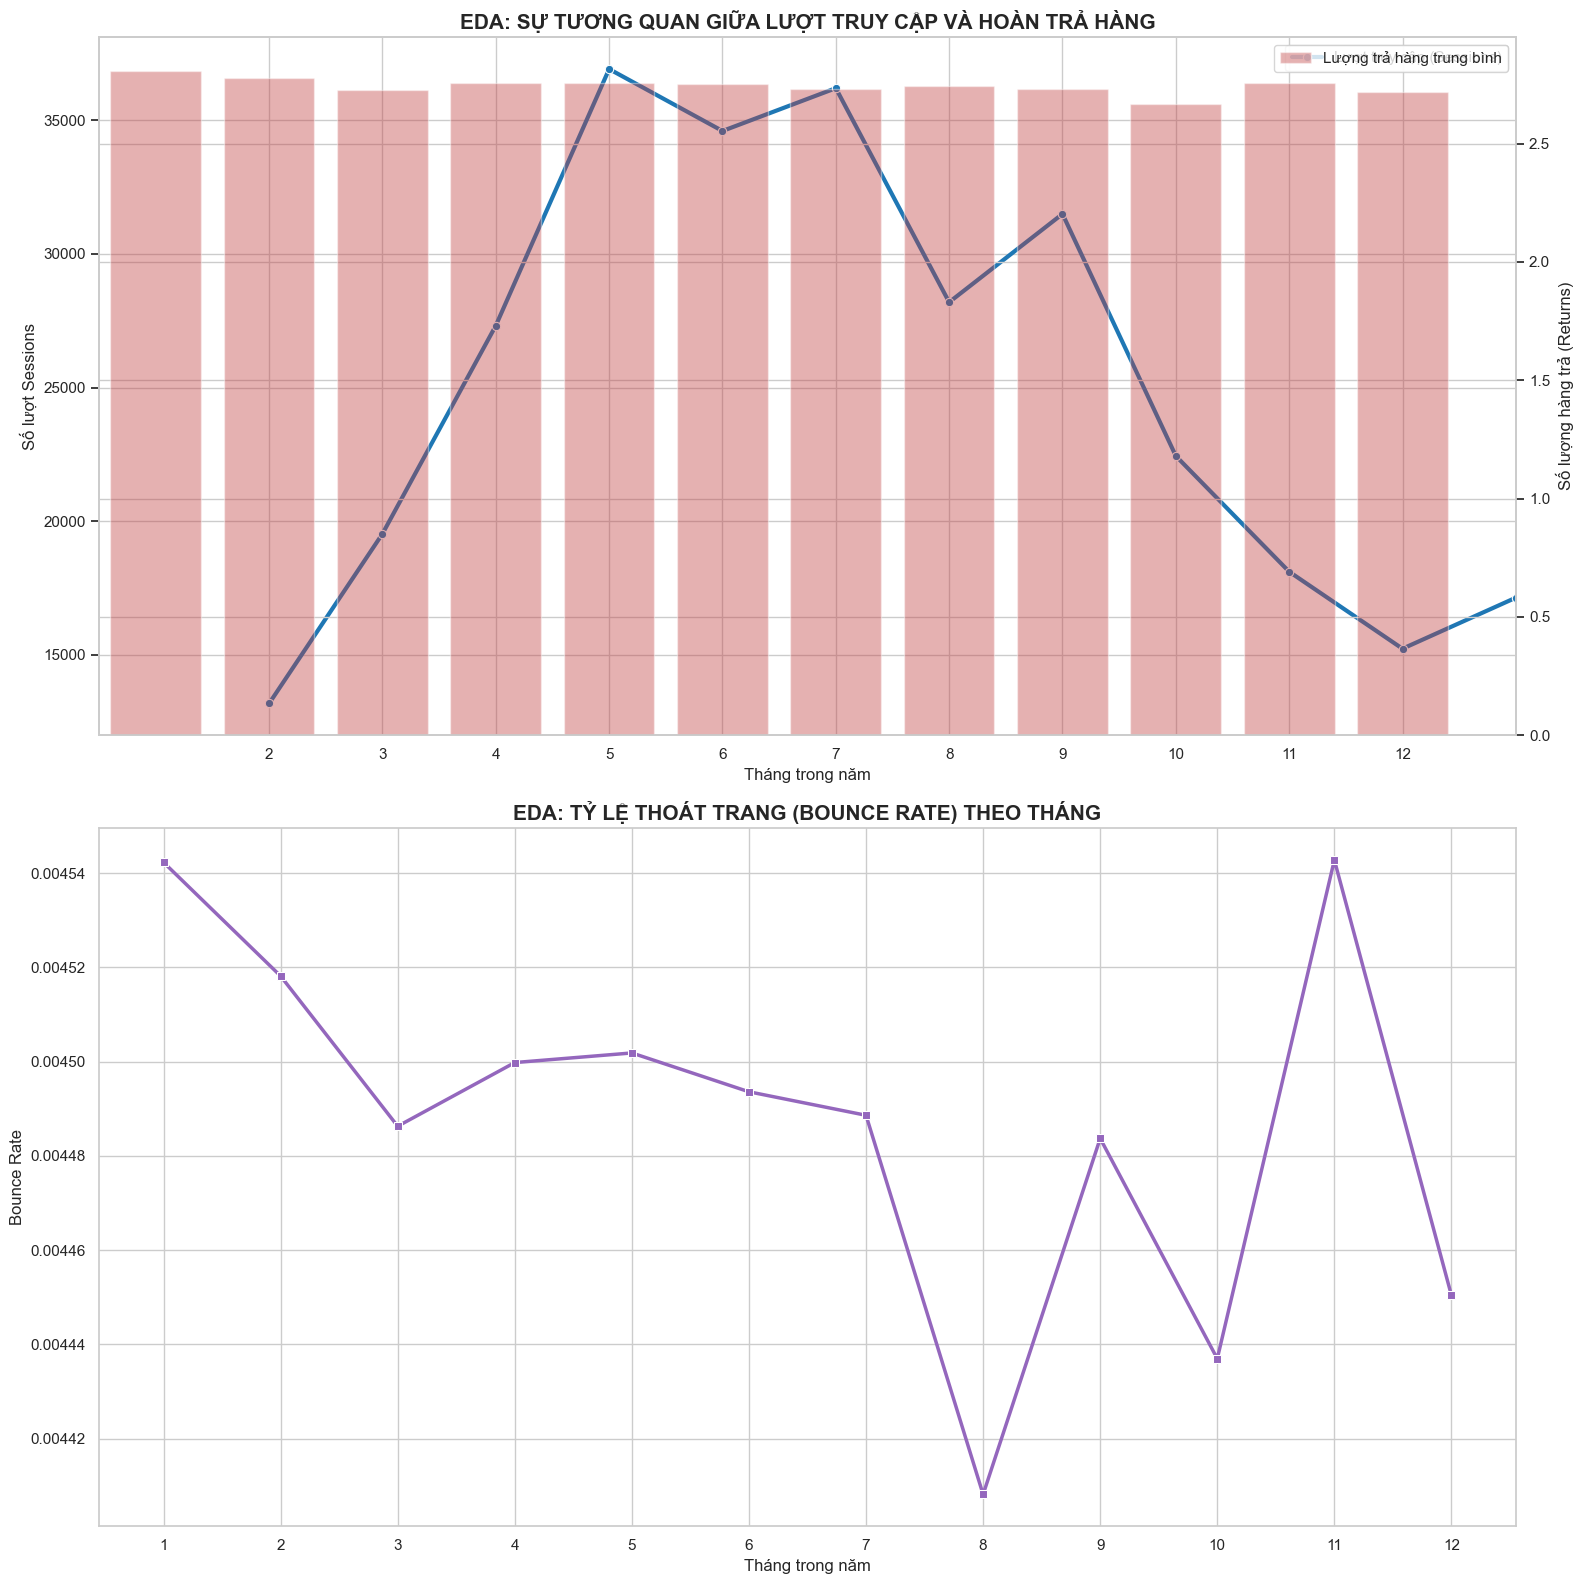

--- CHÌA KHÓA PHÂN TÍCH TRAFFIC & RETURNS ---
Key 9 (Đỉnh Traffic): Tháng 4 - Kiểm tra xem có trùng với tháng Promo không?
Key 10 (Traffic chất lượng nhất): Tháng 8 - Tỷ lệ thoát thấp nhất.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_returns = pd.read_csv('../dataset/returns.csv')
df_traffic = pd.read_csv('../dataset/web_traffic.csv')
df_order_items = pd.read_csv('../dataset/order_items.csv')

# Chuyển đổi định dạng ngày
df_returns['return_date'] = pd.to_datetime(df_returns['return_date'])
df_traffic['date'] = pd.to_datetime(df_traffic['date'])

# Tạo cột Tháng để gom nhóm tính tính mùa vụ (Seasonality)
df_returns['month'] = df_returns['return_date'].dt.month
df_traffic['month'] = df_traffic['date'].dt.month

# ==========================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ THEO THÁNG
# ==========================================

# 2.1. Tính Tỷ lệ trả hàng trung bình (Monthly Return Rate)
# Ta cần tổng lượng bán từ order_items (giả định có cột ngày hoặc map qua bảng orders)
# Ở đây ta tính dựa trên lượng trả hàng trung bình mỗi tháng để xem biến động
monthly_returns = df_returns.groupby('month')['return_quantity'].mean().reset_index()

# 2.2. Tính Traffic trung bình mỗi tháng
monthly_traffic = df_traffic.groupby('month').agg({
    'sessions': 'mean',
    'unique_visitors': 'mean',
    'bounce_rate': 'mean'
}).reset_index()

# ==========================================
# 3. TRỰC QUAN HÓA SỰ TƯƠNG QUAN
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 16))

# --- BIỂU ĐỒ 1: TƯƠNG QUAN GIỮA TRAFFIC VÀ LƯỢNG TRẢ HÀNG ---
ax1 = axes[0]
ax1_twin = ax1.twinx()

# Vẽ lượt truy cập (Sessions)
sns.lineplot(data=monthly_traffic, x='month', y='sessions', marker='o', color='#1f77b4', linewidth=3, label='Lượt truy cập (Sessions)', ax=ax1)
# Vẽ lượng trả hàng (Returns)
sns.barplot(data=monthly_returns, x='month', y='return_quantity', color='#d62728', alpha=0.4, label='Lượng trả hàng trung bình', ax=ax1_twin)

ax1.set_title('EDA: SỰ TƯƠNG QUAN GIỮA LƯỢT TRUY CẬP VÀ HOÀN TRẢ HÀNG', fontsize=15, fontweight='bold')
ax1.set_xlabel('Tháng trong năm')
ax1.set_ylabel('Số lượt Sessions')
ax1_twin.set_ylabel('Số lượng hàng trả (Returns)')
ax1.set_xticks(range(1, 13))

# --- BIỂU ĐỒ 2: CHẤT LƯỢNG TRAFFIC (BOUNCE RATE) ---
ax2 = axes[1]
sns.lineplot(data=monthly_traffic, x='month', y='bounce_rate', marker='s', color='#9467bd', linewidth=2.5, ax=ax2)

ax2.set_title('EDA: TỶ LỆ THOÁT TRANG (BOUNCE RATE) THEO THÁNG', fontsize=15, fontweight='bold')
ax2.set_ylabel('Bounce Rate')
ax2.set_xlabel('Tháng trong năm')
ax2.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# --- XUẤT CÁC "KEYS" PHÂN TÍCH ---
print("--- CHÌA KHÓA PHÂN TÍCH TRAFFIC & RETURNS ---")
peak_traffic_month = monthly_traffic.loc[monthly_traffic['sessions'].idxmax(), 'month']
lowest_bounce_month = monthly_traffic.loc[monthly_traffic['bounce_rate'].idxmin(), 'month']

print(f"Key 9 (Đỉnh Traffic): Tháng {int(peak_traffic_month)} - Kiểm tra xem có trùng với tháng Promo không?")
print(f"Key 10 (Traffic chất lượng nhất): Tháng {int(lowest_bounce_month)} - Tỷ lệ thoát thấp nhất.")

# Phân tích sự vượt trội của tháng 5

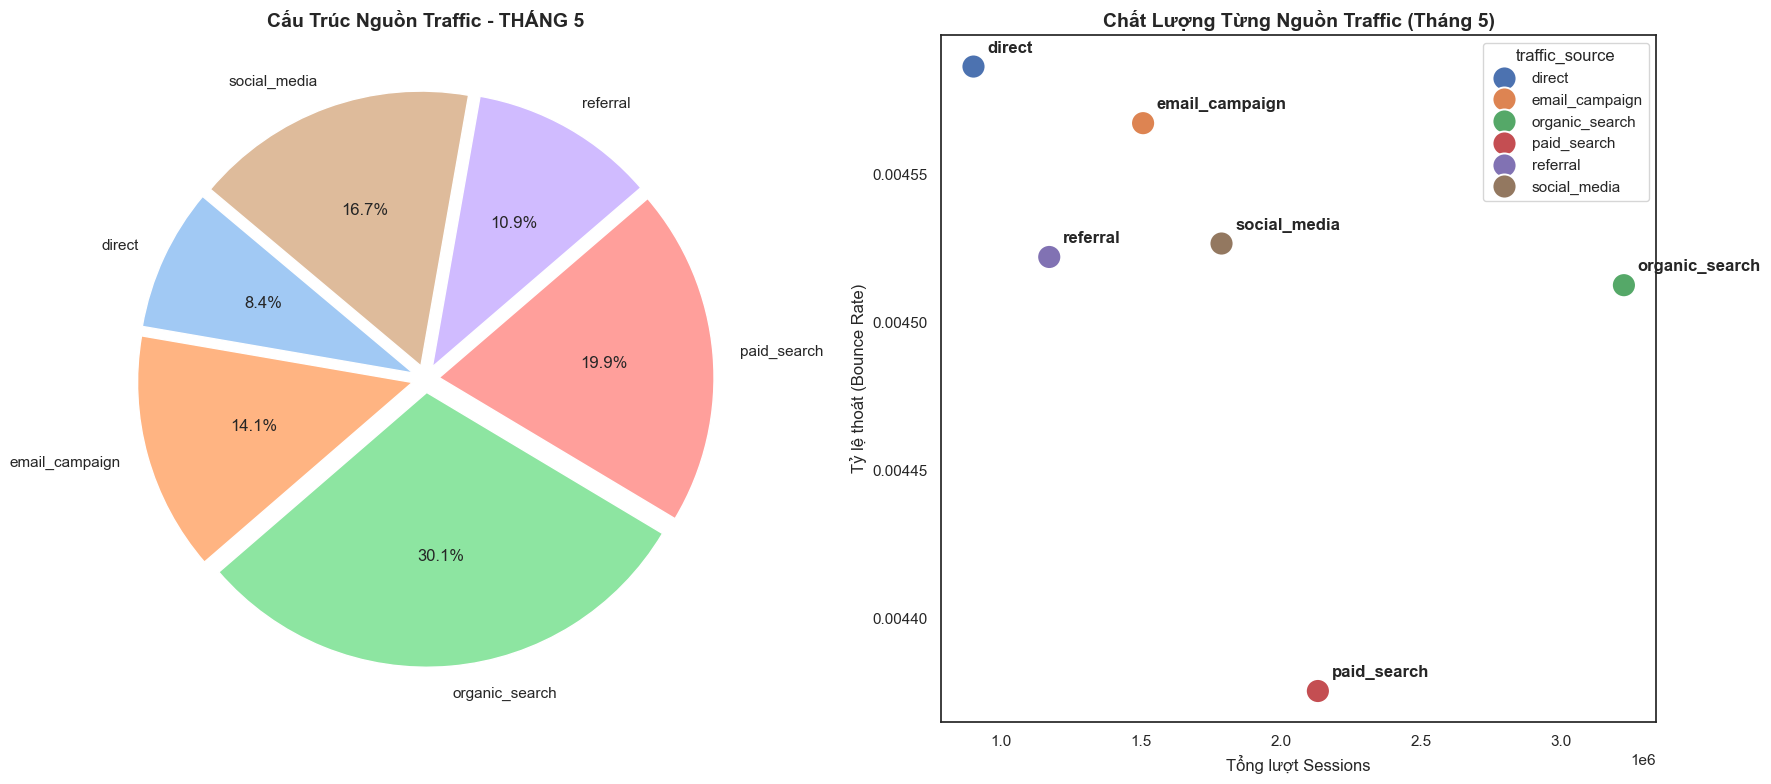

--- CHIẾN THUẬT QUẢNG CÁO THÁNG 5 ---
Key 11 (Nguồn kéo khách chính): organic_search
Key 12 (Nguồn khách chất lượng nhất - ít thoát nhất): paid_search


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df_traffic = pd.read_csv('../dataset/web_traffic.csv')
df_traffic['date'] = pd.to_datetime(df_traffic['date'])
df_traffic['month'] = df_traffic['date'].dt.month

# Lọc riêng dữ liệu Tháng 5 và các tháng còn lại để đối chiếu
df_m5 = df_traffic[df_traffic['month'] == 5]
df_others = df_traffic[df_traffic['month'] != 5]

# ==========================================
# 2. TÍNH TOÁN TỶ TRỌNG NGUỒN TRAFFIC
# ==========================================
# Gom nhóm theo nguồn traffic cho Tháng 5
m5_source = df_m5.groupby('traffic_source')['sessions'].sum().reset_index()
# Gom nhóm theo nguồn traffic cho các tháng khác (để so sánh cấu trúc)
others_source = df_others.groupby('traffic_source')['sessions'].sum().reset_index()

# ==========================================
# 3. TRỰC QUAN HÓA
# ==========================================
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Biểu đồ 1: Cơ cấu nguồn Traffic Tháng 5 ---
axes[0].pie(m5_source['sessions'], labels=m5_source['traffic_source'], 
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'),
            explode=[0.05] * len(m5_source))
axes[0].set_title('Cấu Trúc Nguồn Traffic - THÁNG 5', fontsize=14, fontweight='bold')

# --- Biểu đồ 2: So sánh hiệu suất Traffic Source (Sessions vs Bounce Rate) ---
# Giúp biết nguồn nào "xịn" nhất (vào nhiều nhưng ít thoát)
m5_source_stats = df_m5.groupby('traffic_source').agg({
    'sessions': 'sum',
    'bounce_rate': 'mean'
}).reset_index()

ax2 = axes[1]
sns.scatterplot(data=m5_source_stats, x='sessions', y='bounce_rate', 
                hue='traffic_source', s=300, palette='deep', ax=ax2)

# Thêm nhãn tên nguồn vào các điểm
for i, txt in enumerate(m5_source_stats['traffic_source']):
    ax2.annotate(txt, (m5_source_stats['sessions'].iloc[i], m5_source_stats['bounce_rate'].iloc[i]),
                 xytext=(10, 10), textcoords='offset points', fontweight='bold')

ax2.set_title('Chất Lượng Từng Nguồn Traffic (Tháng 5)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tổng lượt Sessions')
ax2.set_ylabel('Tỷ lệ thoát (Bounce Rate)')

plt.tight_layout()
plt.show()

# --- TỔNG KẾT KEY CHIẾN THUẬT ---
top_source = m5_source.loc[m5_source['sessions'].idxmax(), 'traffic_source']
best_quality_source = m5_source_stats.loc[m5_source_stats['bounce_rate'].idxmin(), 'traffic_source']

print(f"--- CHIẾN THUẬT QUẢNG CÁO THÁNG 5 ---")
print(f"Key 11 (Nguồn kéo khách chính): {top_source}")
print(f"Key 12 (Nguồn khách chất lượng nhất - ít thoát nhất): {best_quality_source}")

# Hiệu quả tài chính của Fall Launch

/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2371109236.py:9: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv('../dataset/order_items.csv')
/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2371109236.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fall_totals_plot, x='Metric', y='Value', palette='vlag', ax=axes[0,0])
/var/folders/1p/5h9bv6vx5x92qyhkv3k7bv0w0000gn/T/ipykernel_58930/2371109236.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_profit.values, y=cat_profit.index, palette='RdYlGn', ax=axes[0,1])
/var/folders/1p/5h9bv6vx5x92qyhkv3k7

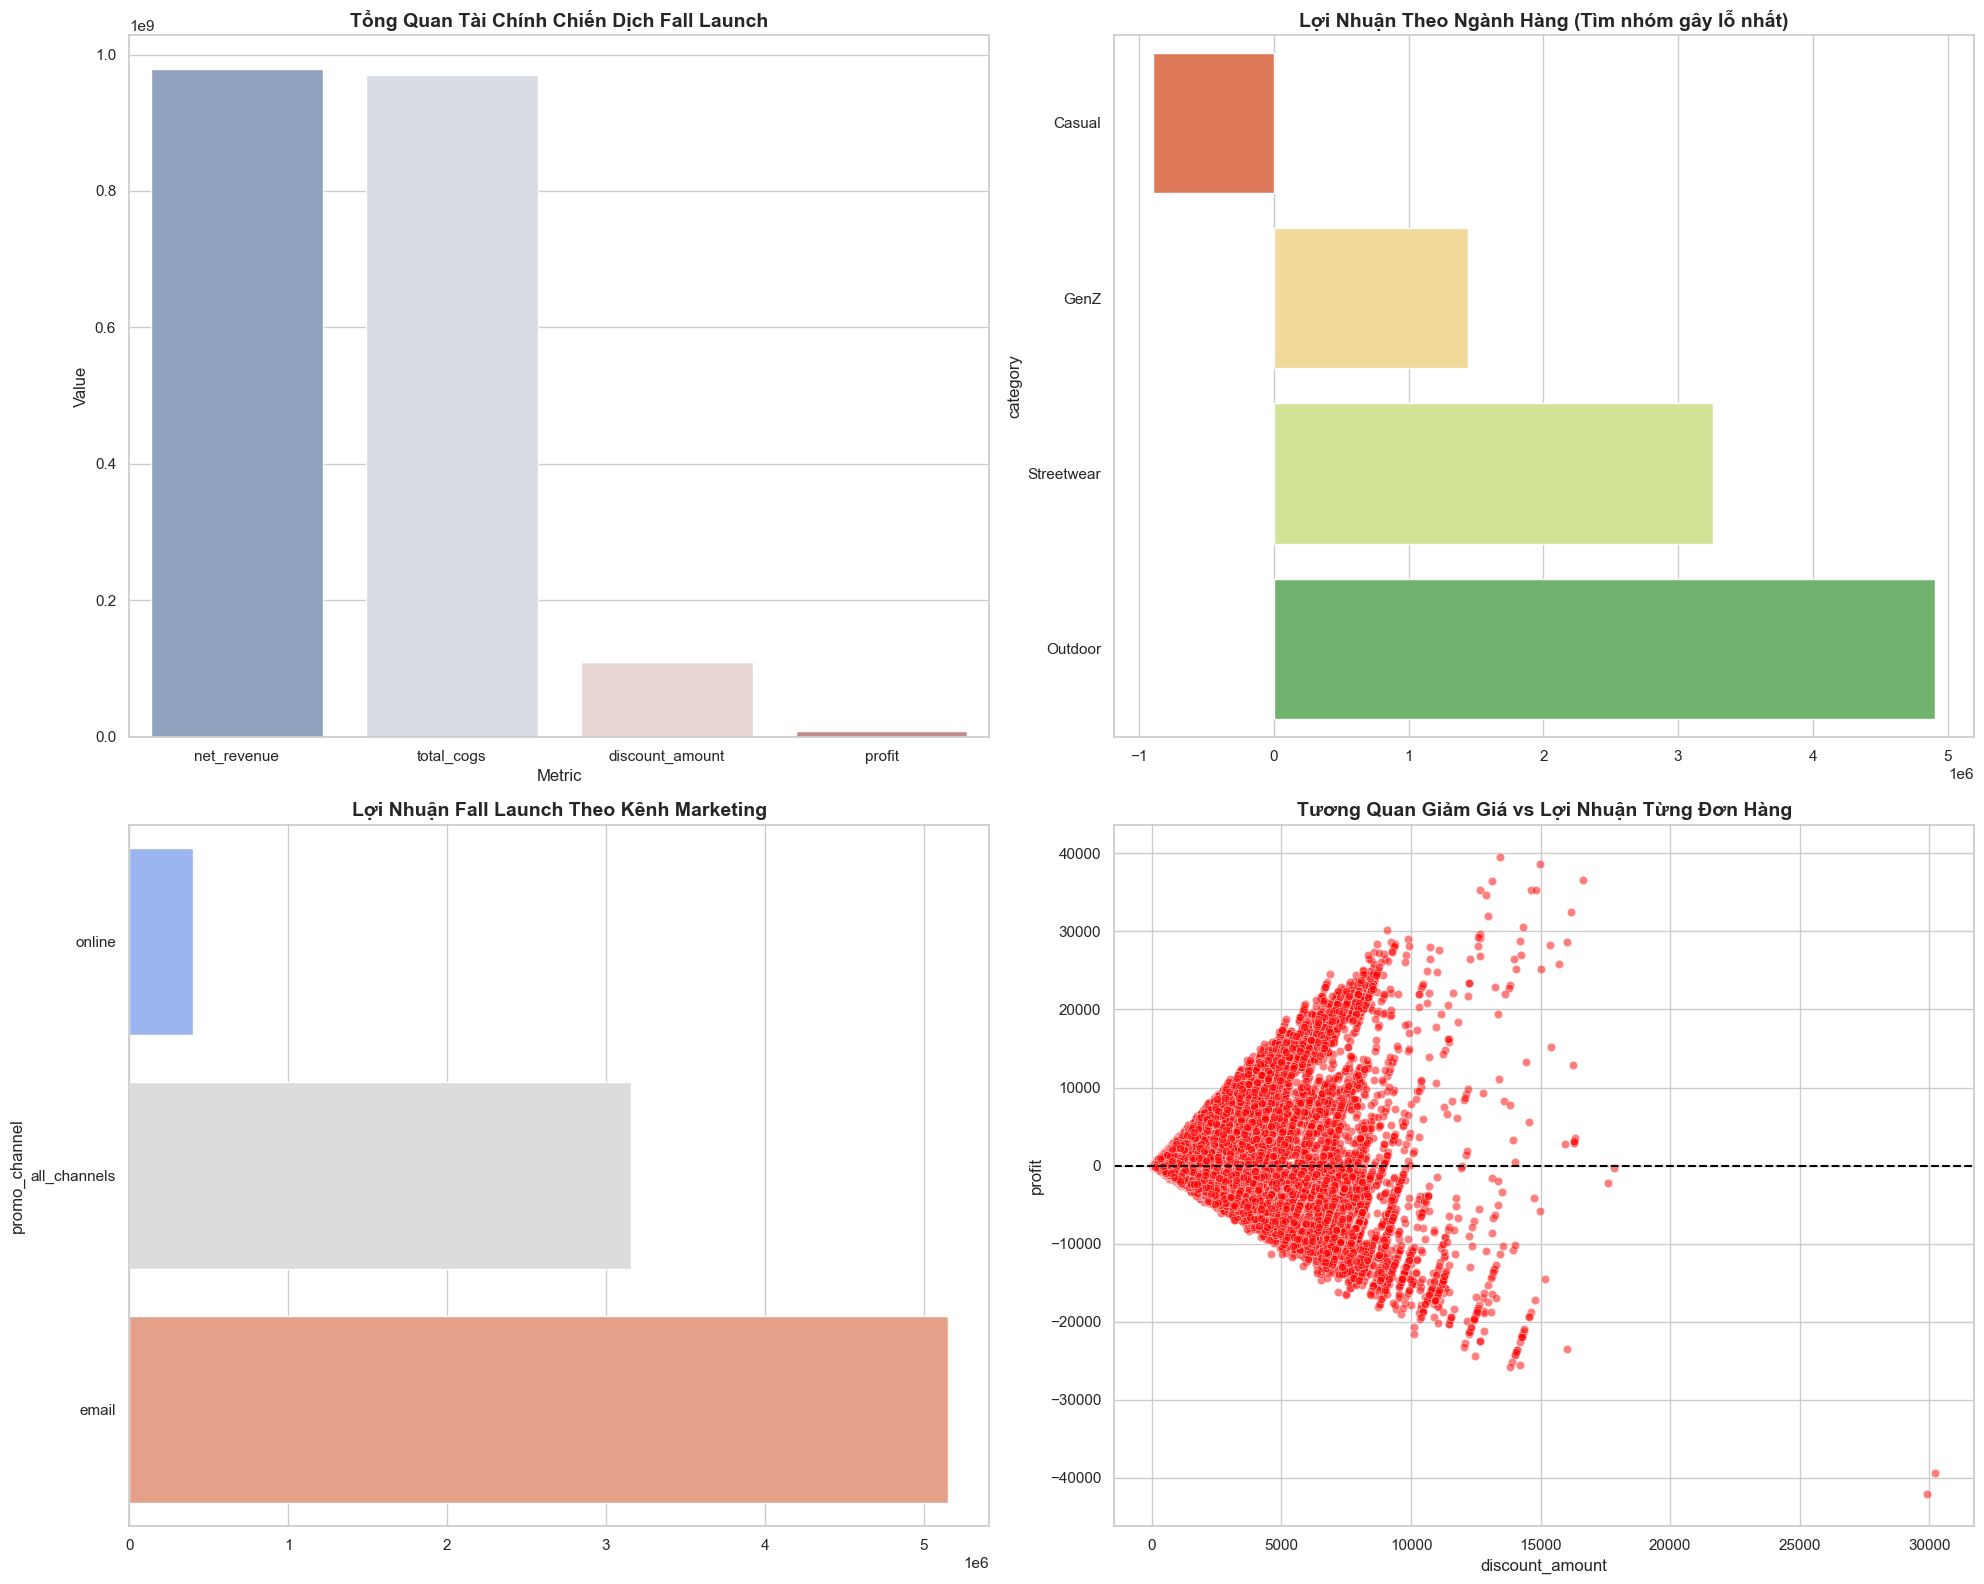

--- CHIẾN LƯỢC GIẢI MÃ THẤT BẠI THÁNG 8 (FALL LAUNCH) ---
Key 13 (Nhóm hàng gây lỗ nặng nhất): Casual
Key 14 (Kênh Marketing kém hiệu quả nhất): online
Key 15 (Mức độ Discount): Nếu cột Discount_amount ở biểu đồ 1 cao xấp xỉ Profit, bạn đang giảm giá quá sâu.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ĐỌC VÀ LỌC DỮ LIỆU CHIẾN DỊCH FALL LAUNCH
# ==========================================
df_promos = pd.read_csv('../dataset/promotions.csv')
df_order_items = pd.read_csv('../dataset/order_items.csv')
df_products = pd.read_csv('../dataset/products.csv')

# Lấy ID của các chiến dịch Fall Launch
fall_launch_ids = df_promos[df_promos['promo_name'].str.contains('Fall Launch', na=False)]['promo_id'].unique()

# Lọc các đơn hàng áp dụng Fall Launch
df_fall = df_order_items[df_order_items['promo_id'].isin(fall_launch_ids)].copy()

# Ghép với bảng sản phẩm để lấy COGS
df_fall = df_fall.merge(df_products[['product_id', 'product_name', 'category', 'cogs']], on='product_id', how='left')

# ==========================================
# 2. TÍNH TOÁN CÁC CHỈ SỐ THUA LỖ
# ==========================================
# Doanh thu thuần = (Qty * Price) - Discount
df_fall['net_revenue'] = (df_fall['quantity'] * df_fall['unit_price']) - df_fall['discount_amount']
# Tổng vốn = Qty * COGS
df_fall['total_cogs'] = df_fall['quantity'] * df_fall['cogs']
# Lợi nhuận = Doanh thu thuần - Tổng vốn
df_fall['profit'] = df_fall['net_revenue'] - df_fall['total_cogs']

# ==========================================
# 3. TRỰC QUAN HÓA TÌM "KEYS" THUA LỖ
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# --- Biểu đồ 1: Cấu trúc Doanh thu vs Chi phí (Phân tích vì sao lỗ) ---
fall_totals = df_fall[['net_revenue', 'total_cogs', 'discount_amount', 'profit']].sum()
fall_totals_plot = pd.DataFrame({'Metric': fall_totals.index, 'Value': fall_totals.values})
sns.barplot(data=fall_totals_plot, x='Metric', y='Value', palette='vlag', ax=axes[0,0])
axes[0,0].set_title('Tổng Quan Tài Chính Chiến Dịch Fall Launch', fontsize=14, fontweight='bold')

# --- Biểu đồ 2: Lợi nhuận theo Category trong Fall Launch ---
cat_profit = df_fall.groupby('category')['profit'].sum().sort_values()
sns.barplot(x=cat_profit.values, y=cat_profit.index, palette='RdYlGn', ax=axes[0,1])
axes[0,1].set_title('Lợi Nhuận Theo Ngành Hàng (Tìm nhóm gây lỗ nhất)', fontsize=14, fontweight='bold')

# --- Biểu đồ 3: Hiệu quả theo Kênh Quảng cáo (Promo Channel) ---
# Ghép lại với promo để lấy channel
df_fall_chan = df_fall.merge(df_promos[['promo_id', 'promo_channel']], on='promo_id')
chan_eval = df_fall_chan.groupby('promo_channel')['profit'].sum().sort_values()
sns.barplot(x=chan_eval.values, y=chan_eval.index, palette='coolwarm', ax=axes[1,0])
axes[1,0].set_title('Lợi Nhuận Fall Launch Theo Kênh Marketing', fontsize=14, fontweight='bold')

# --- Biểu đồ 4: Tương quan Discount vs Profit (Mức độ "đốt tiền") ---
sns.scatterplot(data=df_fall, x='discount_amount', y='profit', alpha=0.5, color='red', ax=axes[1,1])
axes[1,1].axhline(0, color='black', linestyle='--')
axes[1,1].set_title('Tương Quan Giảm Giá vs Lợi Nhuận Từng Đơn Hàng', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# --- XUẤT CÁC "KEYS" THẤT BẠI ---
print(f"--- CHIẾN LƯỢC GIẢI MÃ THẤT BẠI THÁNG 8 (FALL LAUNCH) ---")
print(f"Key 13 (Nhóm hàng gây lỗ nặng nhất): {cat_profit.idxmin()}")
print(f"Key 14 (Kênh Marketing kém hiệu quả nhất): {chan_eval.idxmin()}")
print(f"Key 15 (Mức độ Discount): Nếu cột Discount_amount ở biểu đồ 1 cao xấp xỉ Profit, bạn đang giảm giá quá sâu.")